# Random Polynomial Regression: Sven scan analysis

Sven vs the baseline optimizers on the random-polynomial regression task.

**Data layout.** A run is stored as two files: a light `{scan}/{run_id}.jsonl`
(hyperparameters, per-epoch curves, timings and a per-epoch `svd_summary`) and a heavy
`{scan}/diag/{run_id}.npz` (per-*batch* loss/time series, per-step `num_nonzero_svs`,
and the singular-value spectra).  The scan is loaded **light**; diagnostics are pulled
per run, on demand, only for the runs actually plotted.

The scan runs several model seeds per configuration, so everything below is aggregated
over seeds: curves are seed means with a +/-1 s.d. band, and "best" always means best
seed-mean, never a lucky single run.

The shared code lives in [`scan_analysis.py`](scan_analysis.py) and
[`sv_diagnostics.py`](sv_diagnostics.py).

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

import scan_analysis as sa
from style import set_style, clipped_yerr, DATASET_TITLES

set_style()

In [2]:
SCAN      = 'polynomial_scan'
TITLE     = DATASET_TITLES['polynomial']
PLOT_DIR  = 'plots_v2/polynomial'

# Baselines to overlay, in plot order -- EVERY optimizer the scan contains (filtered
# against what is actually present, so the list is safe on partial scans).  AdamW / MuonW
# are Adam / Muon at their PyTorch-default weight decay (RERUNS_NEEDED.md item 0).
BASELINES = ['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'AdamW', 'LBFGS',
             'Muon', 'MuonW', 'SOAP', 'Shampoo', 'KFAC', 'HIG', 'JD_UPGrad']

# Model selection: every 'best' config is the best SEED-MEAN final VALIDATION loss -- the one
# selection metric in every notebook.  Tables show the train loss (and accuracy) alongside.
METRIC = 'final_val_loss'

# The learning rate the singular-value section (and the k sweep) zooms in on.
FOCUS_LR = 0.1

In [3]:
scan = sa.load_scan(SCAN, TITLE, PLOT_DIR, metric=METRIC)
BASELINES = [b for b in BASELINES if b in scan.baselines]
print(f'plots -> {scan.plot_dir.resolve()}')
print(f'baselines plotted: {BASELINES}')
print(f'baselines available: {scan.baselines}')

Loaded 711 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
polynomial_scan: 711 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[0.0001, 0.001, 0.01]
  94 diverged run(s), excluded from seed means: {'LBFGS': 88, 'KFAC': 4, 'SOAP': 2}
plots -> /Users/sambt/iaifi/sv3/analysis/plots_v2/polynomial
baselines plotted: ['SGD', 'PolyakSGD', 'RMSprop', 'Adam', 'AdamW', 'LBFGS', 'Muon', 'SOAP', 'Shampoo', 'KFAC', 'HIG', 'JD_UPGrad']
baselines available: ['Adam', 'AdamW', 'HIG', 'JD_UPGrad', 'KFAC', 'LBFGS', 'Muon', 'PolyakSGD', 'RMSprop', 'SGD', 'SOAP', 'Shampoo']


In [4]:
# Standalone (NPROC=1) timings: the best config of every method re-run alone on a GPU
# with the SAME seeds (experiment_results/<scan>_timing/, same run_ids), joined by run_id.
# The scan's own wall times are inflated by shard contention; these are the honest ones.
timing = sa.attach_standalone_times(scan)

Loaded 65 runs from ../experiment_results/_cache/polynomial_scan_timing.slim.pkl (slim cache)
[standalone] 65 runs in polynomial_scan_timing/, 65 joined; final-val-loss deviation vs scan: max 0.00e+00, median 0.00e+00


## 2. Best configuration per method

Each method's configuration is scored by its **seed-mean** final validation loss.

In [5]:
summary = sa.summary_table(scan, baselines=BASELINES)
summary

,method,config,n_seeds,n_diverged,n_missing,final_val_loss,final_val_loss_std,final_val_loss_min,final_train_loss,sharded_time_s,standalone_time_s
0,HIG,"lr=0.1, tau=0.01",5,0,0,0.003039,0.000996,0.002052,0.002272,151.260698,78.254405
1,JD_UPGrad,"lr=0.001, aggregator=UPGrad, inner_optimizer=Adam",5,0,0,0.007276,0.000394,0.006710,0.005714,89.058085,53.278005
2,PolyakSGD,,5,0,0,0.008064,0.001266,0.006699,0.006868,52.555227,33.118509
3,Muon,lr=0.001,5,0,0,0.008931,0.001775,0.007601,0.006506,64.007087,31.685743
4,SOAP,lr=0.001,5,0,0,0.009026,0.001440,0.007685,0.006887,67.785778,31.663537
5,Adam,lr=0.01,5,0,0,0.012267,0.002823,0.009704,0.019010,50.343466,33.248703
6,AdamW,lr=0.01,5,0,0,0.012267,0.002823,0.009704,0.019010,50.904220,33.209990
7,Sven,"k=32, lr=0.1, rtol=0.0001",5,0,0,0.012307,0.003284,0.009704,0.010362,125.148708,84.027330
8,RMSprop,lr=0.001,5,0,0,0.013844,0.002179,0.010846,0.012316,50.058074,33.516417
9,LBFGS,"lr=0.5, lbfgs_max_iter=3, lbfgs_history_size=2",4,1,0,0.013899,0.004321,0.011167,0.008922,205.905944,93.178105


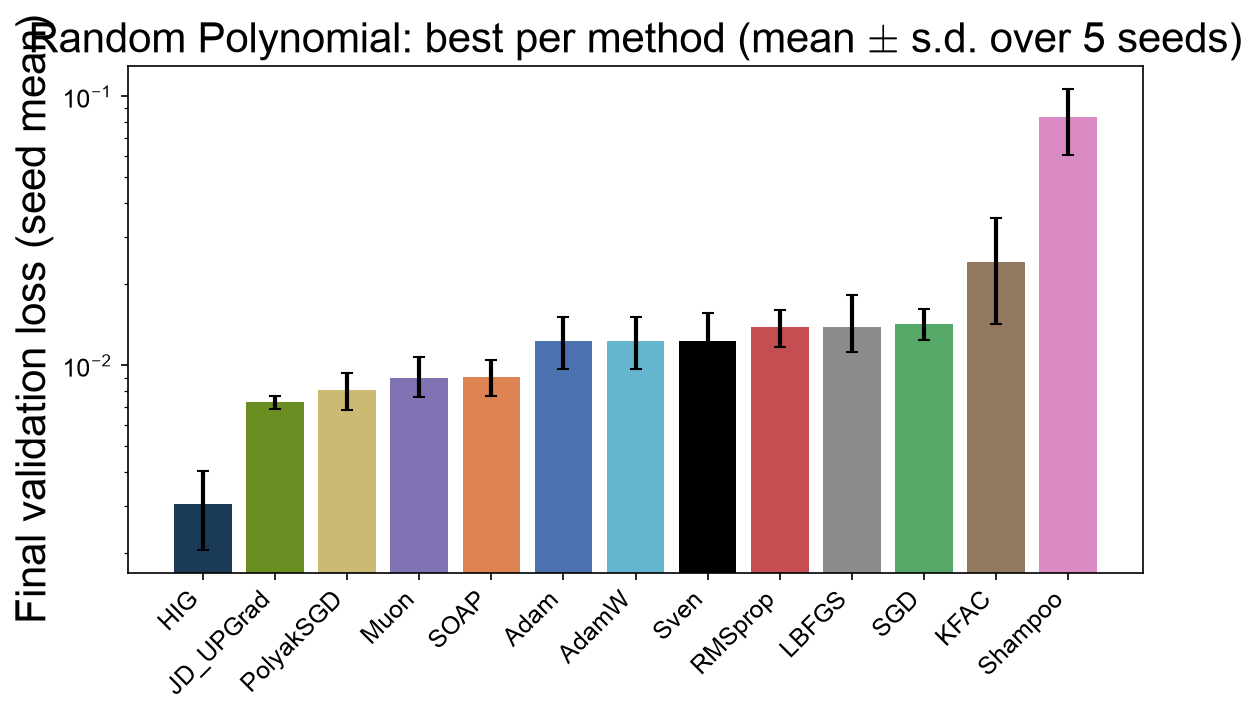

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
# seed mean; error bar = +/-1 std with the lower end clipped at the lowest seed (log axis)
ax.bar(x, summary['final_val_loss'],
       yerr=clipped_yerr(summary['final_val_loss'], summary['final_val_loss_std'],
                         summary['final_val_loss_min']),
       capsize=3, color=[sa.method_colors(BASELINES)[m] for m in summary['method']])
ax.set_xticks(x)
ax.set_xticklabels(summary['method'], rotation=45, ha='right')
ax.set_ylabel('Final validation loss (seed mean)')
ax.set_yscale('log')
ax.set_title(f'{scan.title}: best per method (mean $\\pm$ s.d. over {len(scan.seeds)} seeds)')
fig.tight_layout()
scan.save(fig, 'best_per_method.pdf')
plt.show()

## 3. Convergence

Best Sven against the best of each baseline, versus epoch and versus wall time.
Shaded bands are the seed spread.

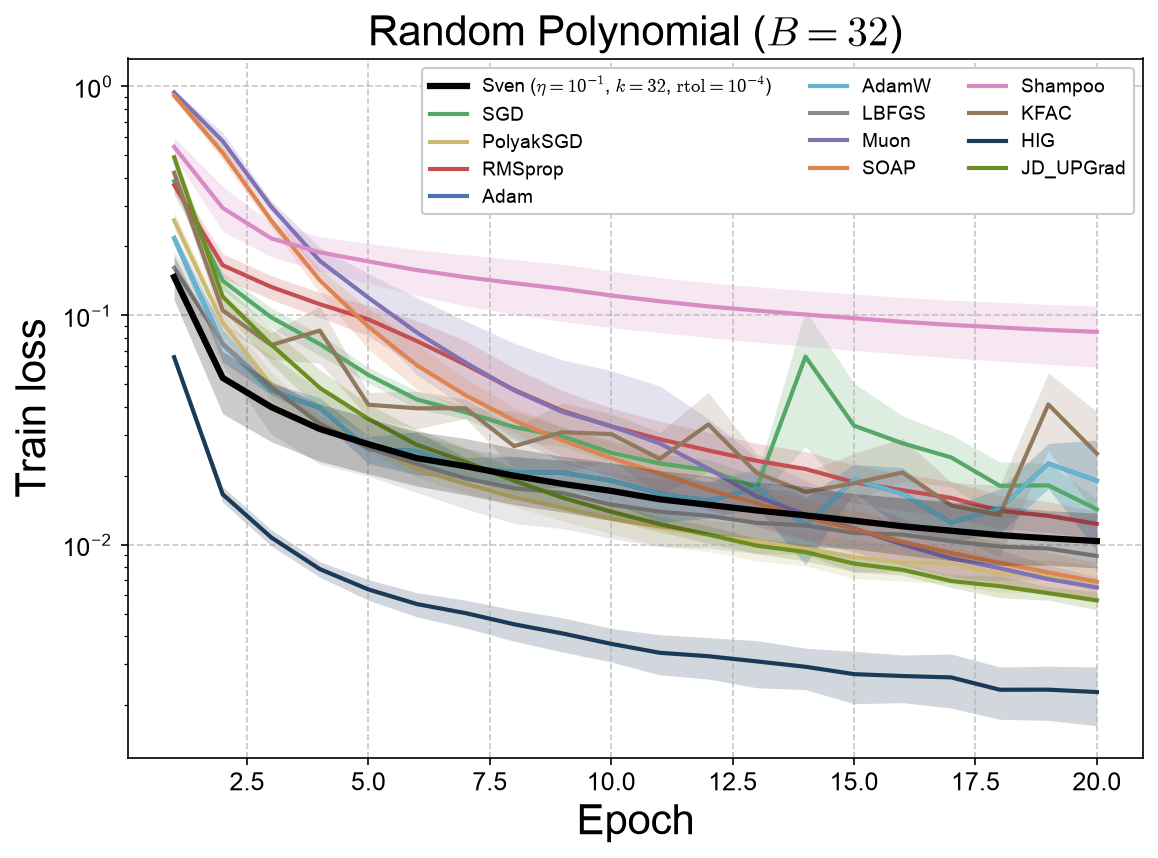

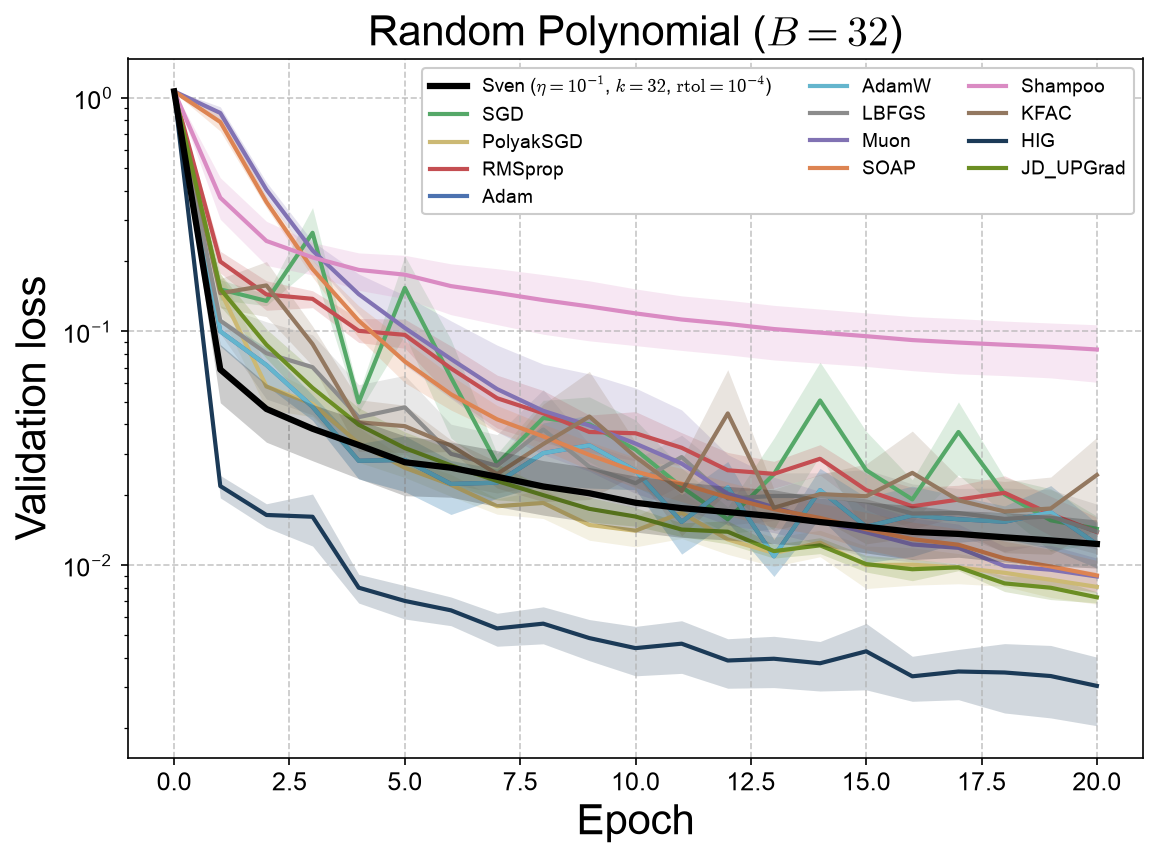

In [7]:
for which in ['train', 'val']:
    fig, ax = plt.subplots(figsize=(8, 6))
    sa.plot_best_curves(scan, ax, which=which, versus='epoch', baselines=BASELINES)
    ax.set_title(f'{scan.title} ($B = {scan.B}$)')
    ax.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
    ax.legend(ncol=3, loc='upper right', frameon=True, framealpha=1, fontsize=9)
    fig.tight_layout()
    scan.save(fig, f'{which}_loss_best.pdf')
    plt.show()

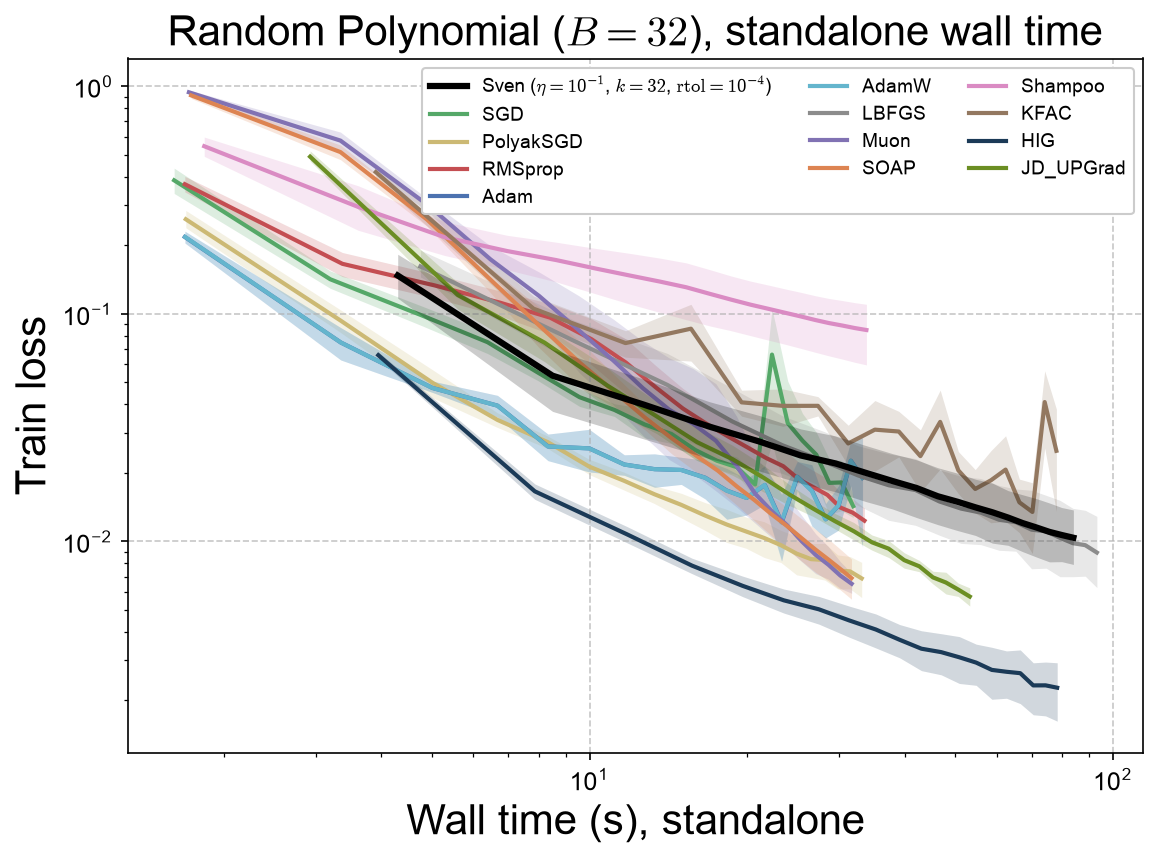

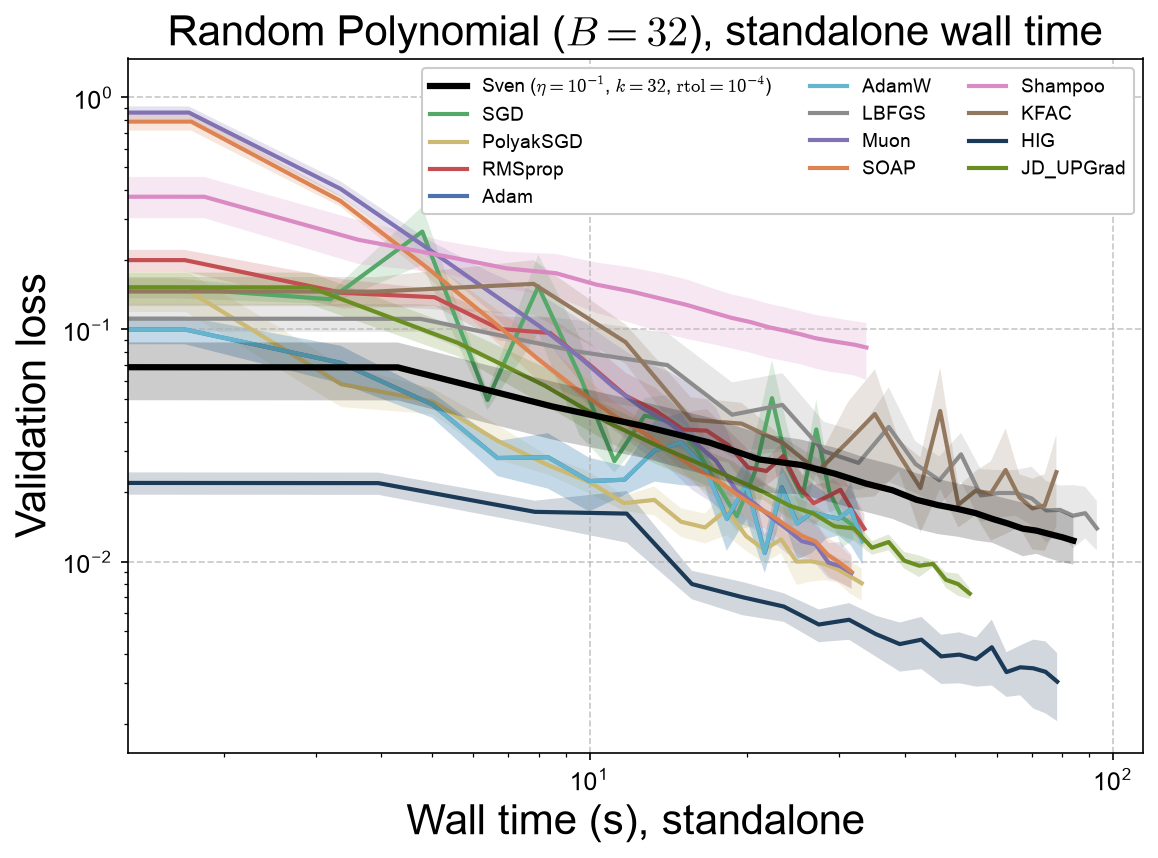

In [8]:
for which in ['train', 'val']:
    fig, ax = plt.subplots(figsize=(8, 6))
    # time_key='auto': standalone (one run per GPU) epoch times when attach_standalone_times
    # found them, else the scan's own shard-inflated times -- the x label says which
    sa.plot_best_curves(scan, ax, which=which, versus='time', baselines=BASELINES)
    ax.set_xscale('log')
    ax.set_title(f'{scan.title} ($B = {scan.B}$)' + (', standalone wall time' if sa.has_standalone(scan) else ', sharded wall time'))
    ax.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
    ax.legend(ncol=3, loc='upper right', frameon=True, framealpha=1, fontsize=9)
    fig.tight_layout()
    scan.save(fig, f'walltime_vs_{which}_loss_best.pdf')
    plt.show()

In [9]:
if scan.has_acc:
    fig, ax = plt.subplots(figsize=(8, 6))
    sa.plot_best_curves(scan, ax, which='val_acc', versus='epoch', baselines=BASELINES)
    ax.set_title(f'{scan.title} ($B = {scan.B}$)')
    ax.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
    ax.legend(ncol=3, loc='lower right', frameon=True, framealpha=1, fontsize=9)
    fig.tight_layout()
    scan.save(fig, 'val_acc_best.pdf')
    plt.show()

### Effect of $k$

Loss curves across the truncation rank $k$ at a fixed $(\eta, \mathrm{rtol})$, with the
best SGD run as a reference.

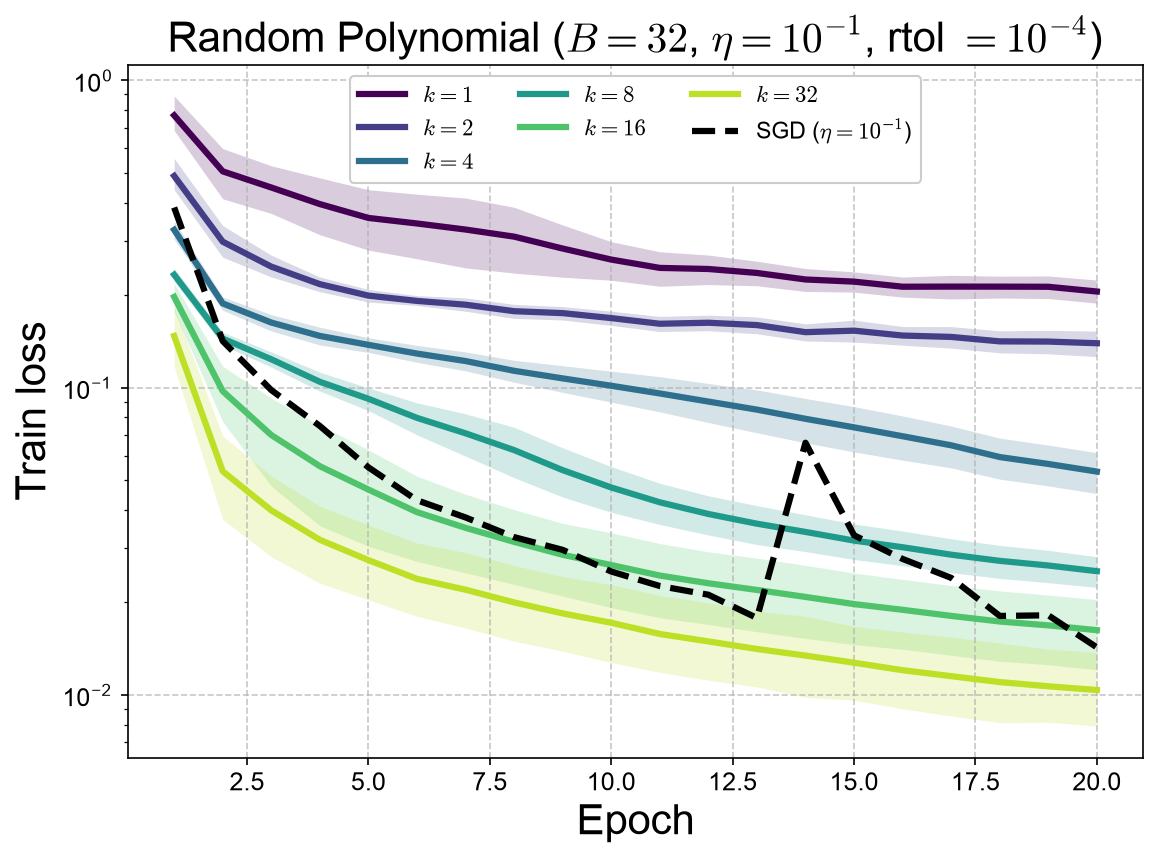

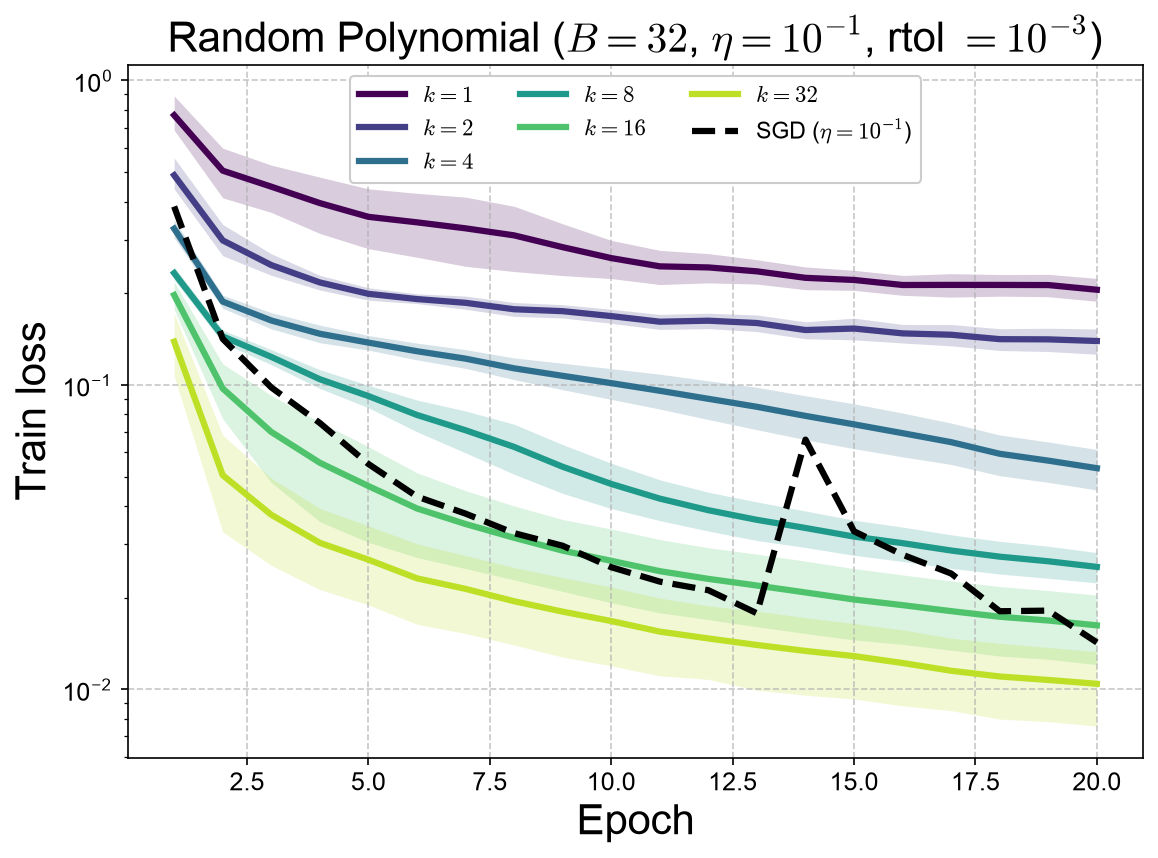

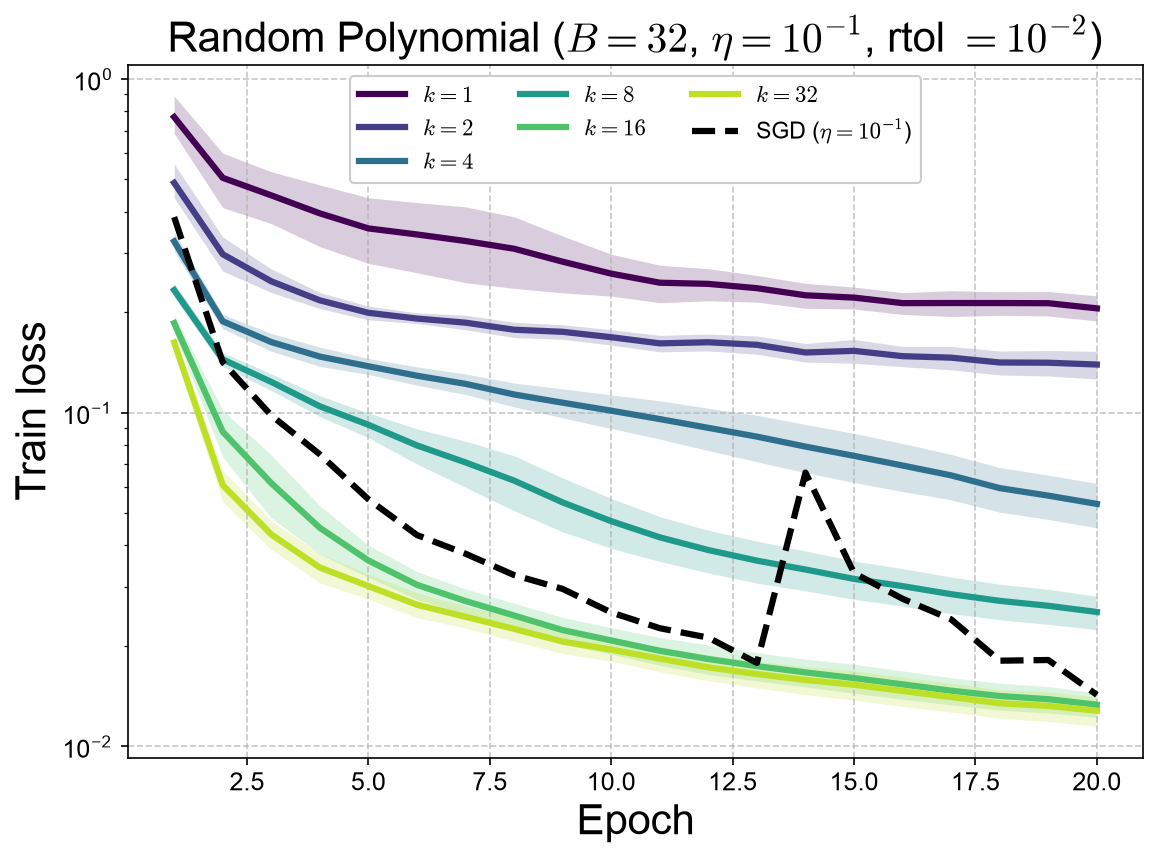

In [10]:
for rtol in scan.rtols:
    fig, ax = plt.subplots(figsize=(8, 6))
    sa.plot_k_sweep(scan, ax, lr=FOCUS_LR, rtol=rtol, which='train')
    ax.set_title(f'{scan.title} ($B = {scan.B}$, $\\eta = {sa.fmt(FOCUS_LR)}$, '
                 f'rtol $= {sa.fmt(rtol)}$)')
    ax.grid(axis='both', linestyle='--', alpha=0.7)
    ax.legend(ncol=3, loc='upper center', frameon=True, framealpha=1, fontsize=11)
    fig.tight_layout()
    scan.save(fig, f'train_loss_k_sweep_lr{FOCUS_LR}_rtol{rtol:g}.pdf')
    plt.show()

### Batch-resolved training loss

The per-batch series lives in `diag/*.npz`, so this reads one npz per configuration
shown (first seed of each -- batch-level traces are seed-specific noise anyway).

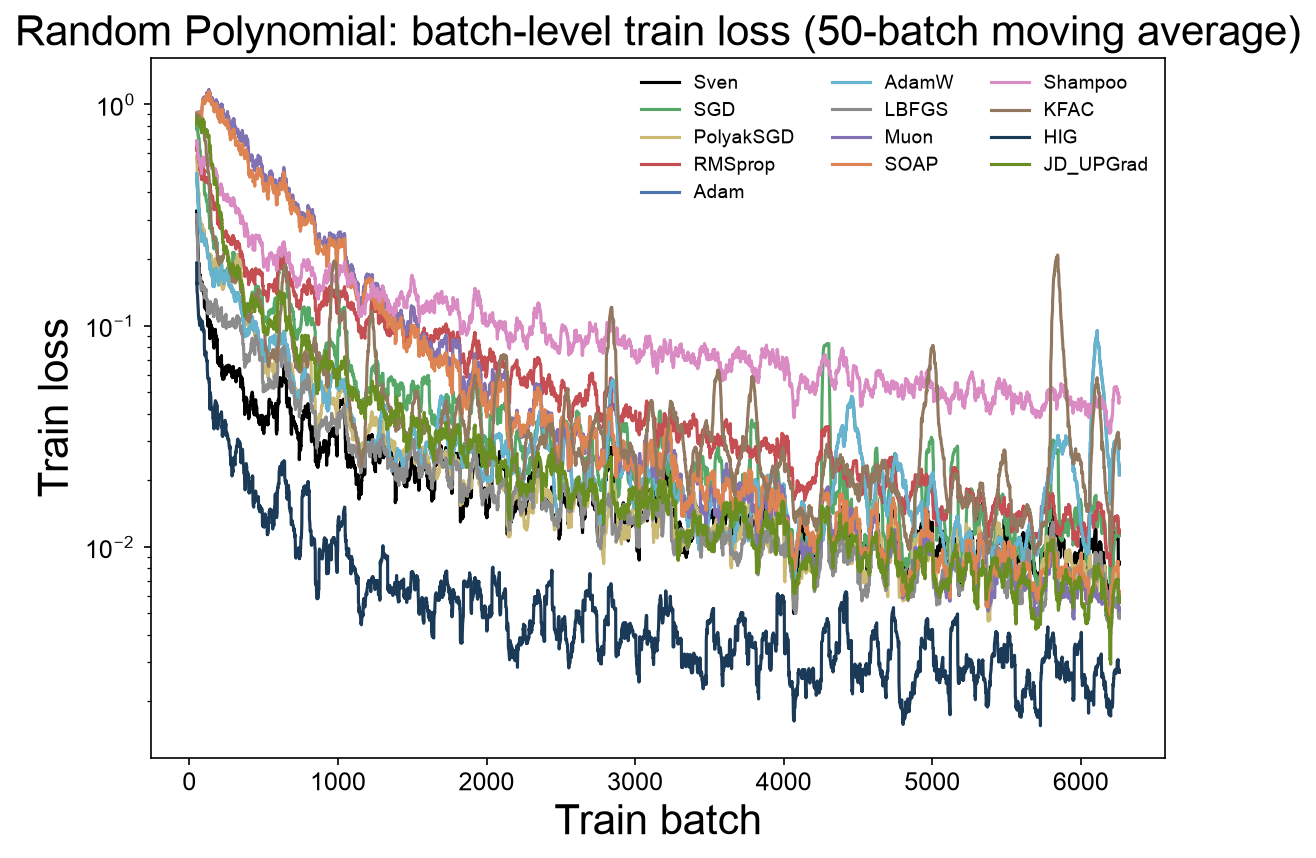

In [11]:
# keep configs and labels paired, so a method with no runs drops from both
pairs = [('Sven', scan.best_sven())] + [(o, scan.best_baseline(o)) for o in BASELINES]
pairs = [(m, c) for m, c in pairs if c is not None]
labels = [m for m, _ in pairs]

fig, ax = plt.subplots(figsize=(8, 6))
cmap = sa.method_colors(BASELINES)
sa.plot_batch_loss(scan, ax, [c for _, c in pairs], smooth_batches=50,
                   labels=labels, colors=[cmap[m] for m in labels])
ax.set_title(f'{scan.title}: batch-level train loss (50-batch moving average)')
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
scan.save(fig, 'train_loss_batchwise_best.pdf')
plt.show()

## 4. Sven hyperparameter sensitivity

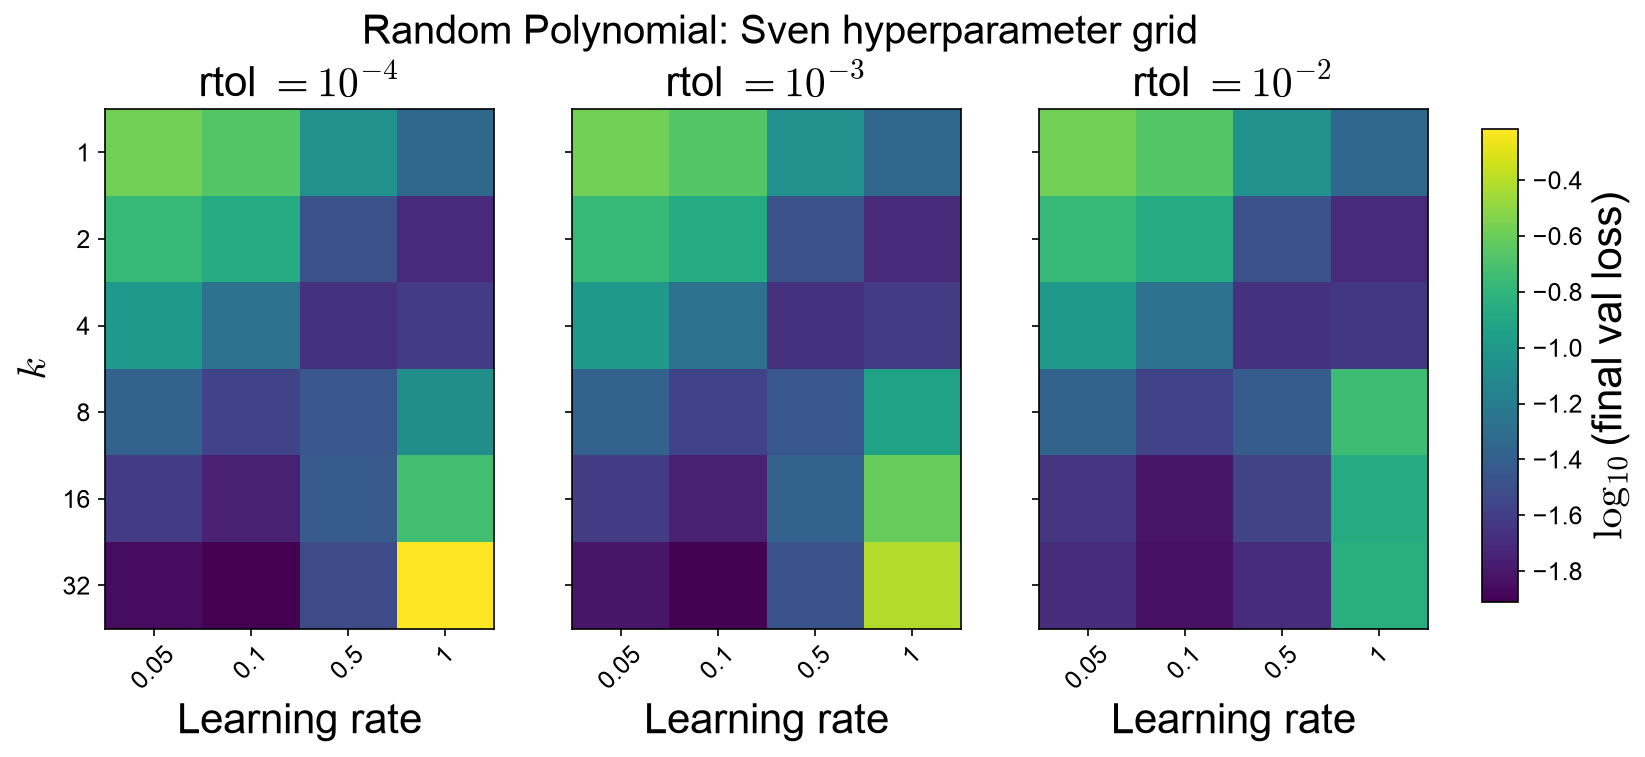

In [12]:
fig, axes = plt.subplots(1, len(scan.rtols), figsize=(4 * len(scan.rtols), 4.5))
im = sa.plot_hparam_heatmap(scan, axes)
fig.subplots_adjust(right=0.86)
cbar = fig.colorbar(im, cax=fig.add_axes([0.89, 0.15, 0.02, 0.7]))
cbar.set_label('$\\log_{10}$(final val loss)')
fig.suptitle(f'{scan.title}: Sven hyperparameter grid', y=1.02)
scan.save(fig, 'sven_heatmap_by_rtol.pdf')
plt.show()

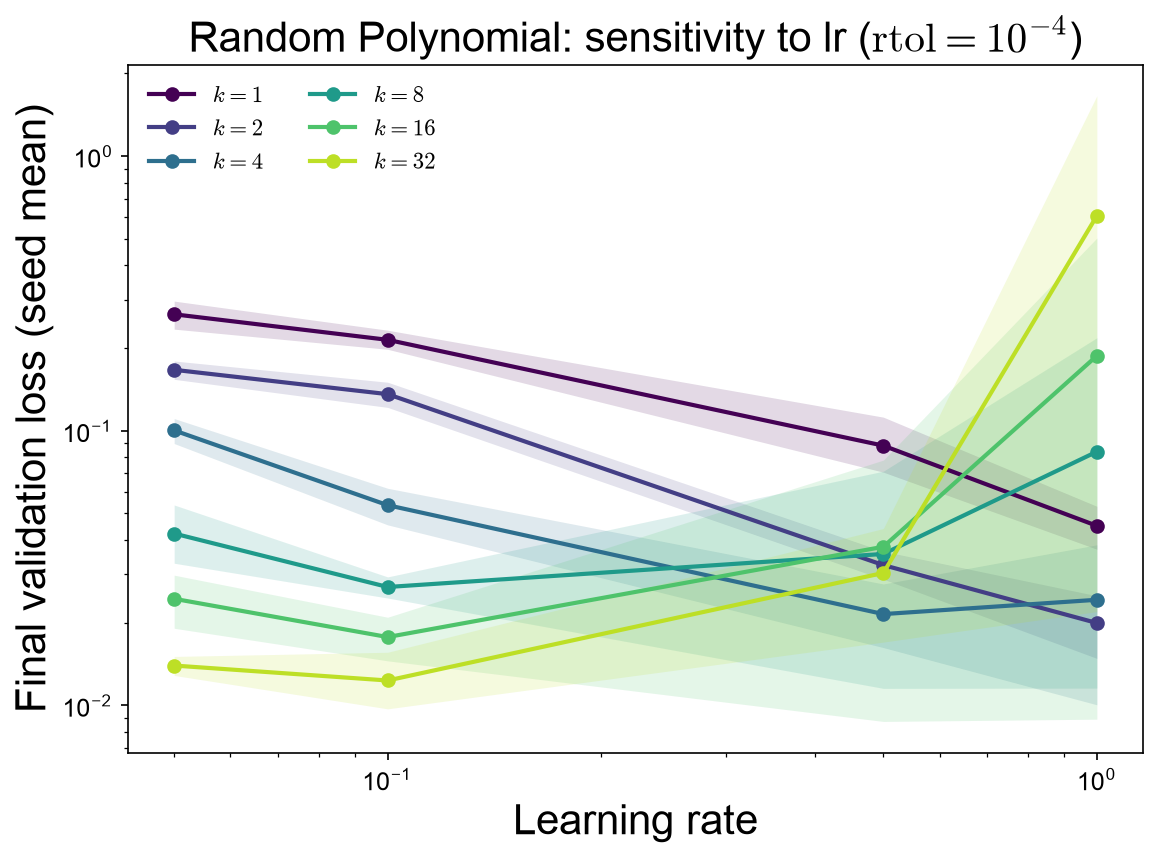

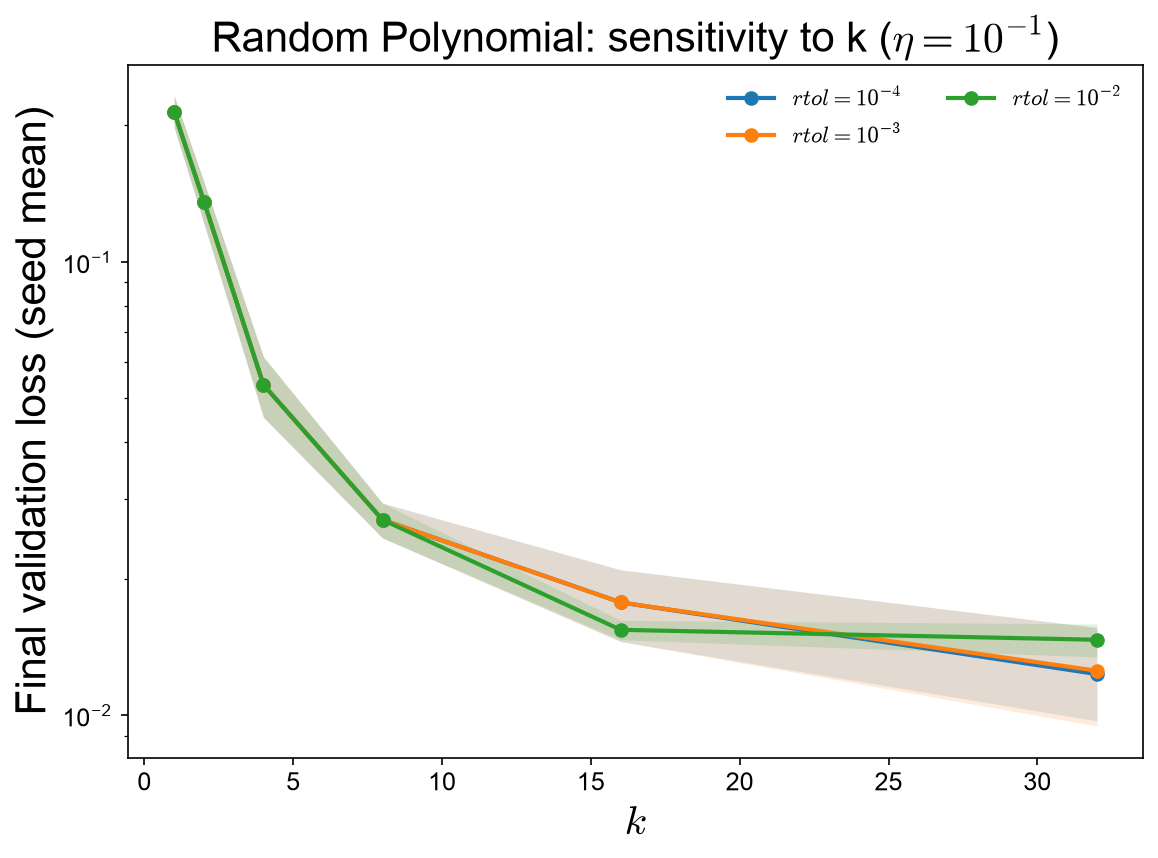

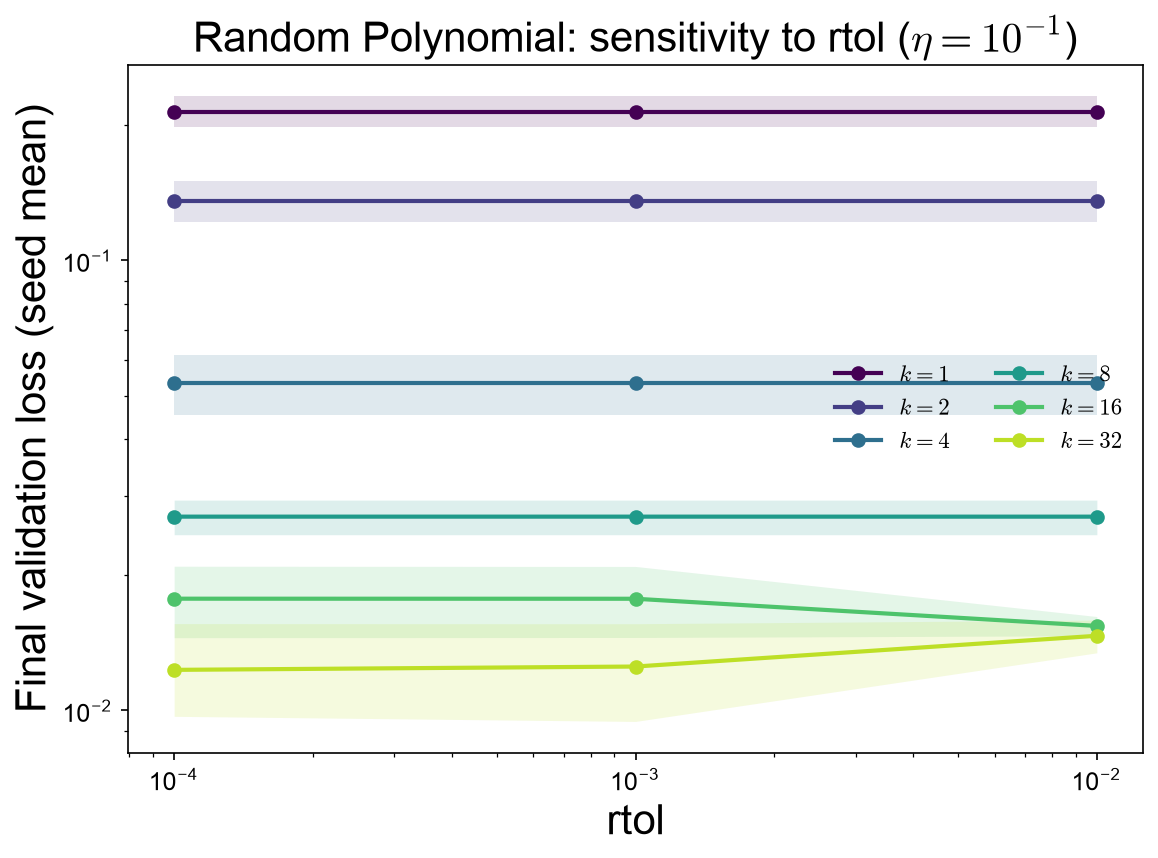

In [13]:
for x, lines, fname in [('lr', 'k', 'lr_sensitivity'),
                        ('k', 'rtol', 'k_effect'),
                        ('rtol', 'k', 'rtol_effect')]:
    fig, ax = plt.subplots(figsize=(8, 6))
    # one point = one config: seed mean, +/-1 std seed band; the third axis is pinned
    # at its value in the best Sven config (third='min' gives the old envelope)
    pinned = sa.plot_sensitivity(scan, ax, x=x, lines=lines)
    other = ({'k', 'lr', 'rtol'} - {x, lines}).pop()
    other_tex = {'k': 'k', 'lr': '\\eta', 'rtol': '\\mathrm{rtol}'}[other]
    ax.set_title(f'{scan.title}: sensitivity to {x} (${other_tex} = {sa.fmt(pinned)}$)')
    ax.legend(ncol=2, fontsize=11)
    fig.tight_layout()
    scan.save(fig, f'{fname}.pdf')
    plt.show()

## 5. Singular values

Three views, all built from `diag/*.npz` via
[`sv_diagnostics.py`](sv_diagnostics.py):

1. **Rank vs train batch** -- `num_nonzero_svs` at $k = B$, where the count is not
   clipped by the cap, so it reads as the rtol-rank of the batch Jacobian. One line
   per `rtol`.
2. **SVs used vs train batch** -- the same quantity swept over $k$ at fixed
   $(\eta, \mathrm{rtol})$, showing where it saturates against the cap (dotted lines).
3. **Spectrum shape per epoch** -- $\sigma_i/\sigma_0$ averaged over the batches in
   each epoch, coloured by epoch.

Note the spectra are saved every `svd_summary['spectra_every']`-th step, so steps are
binned into epochs via `svs_step`; slicing `svs` by `len(svs)//n_epoch` (as the old
notebooks did) mis-bins them.

### 5.1 Rank (nonzero SVs) vs train batch

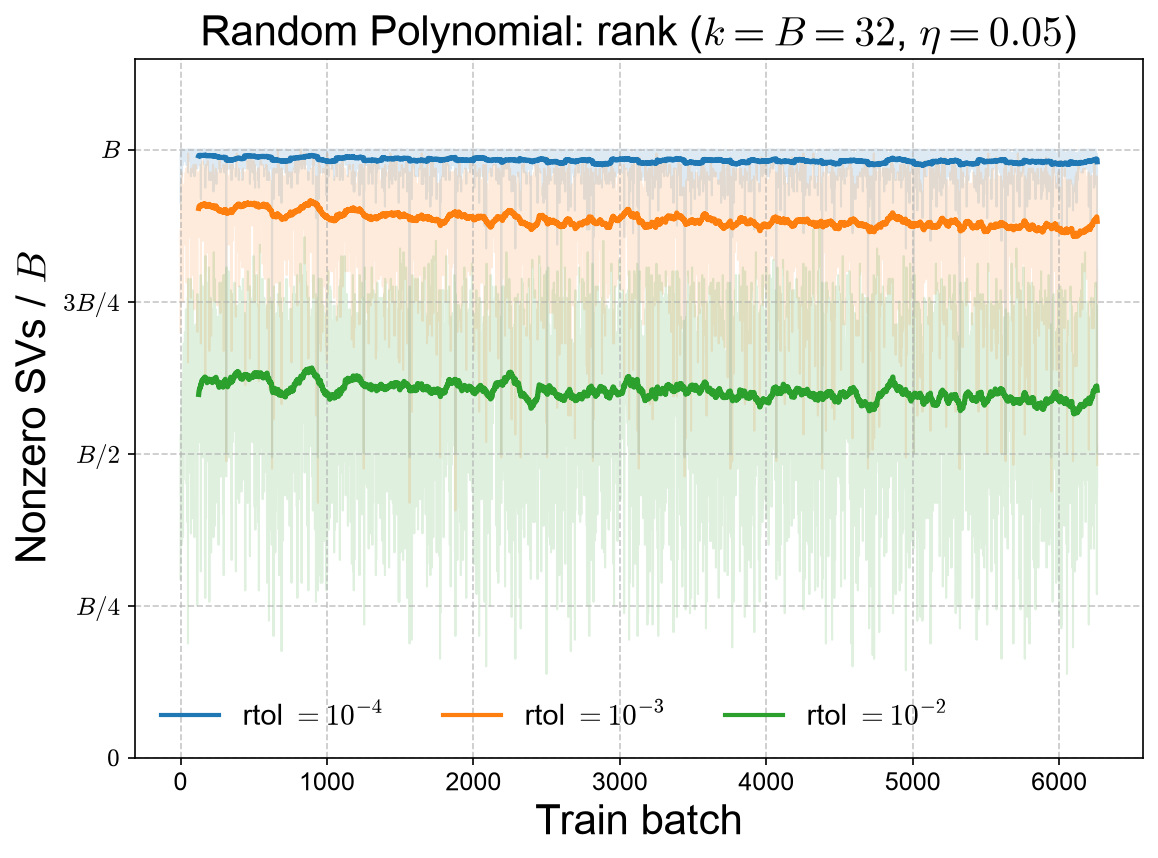

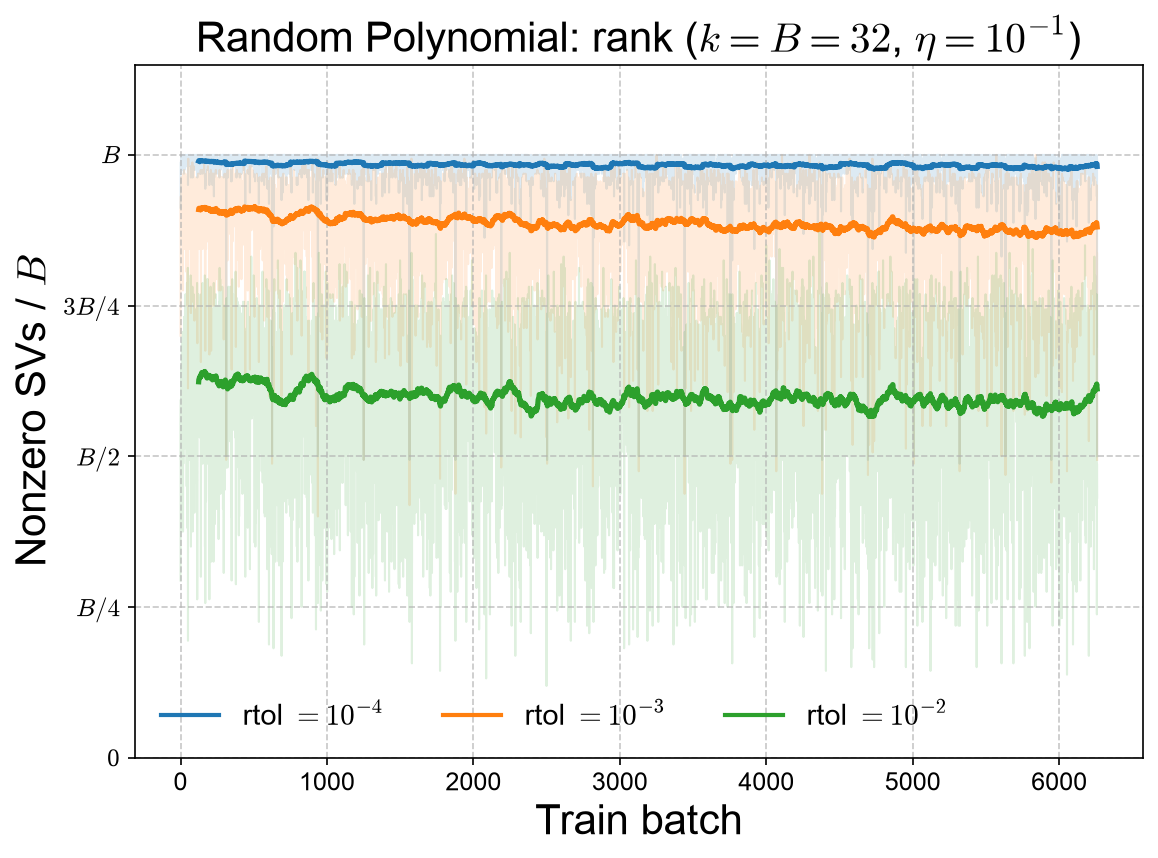

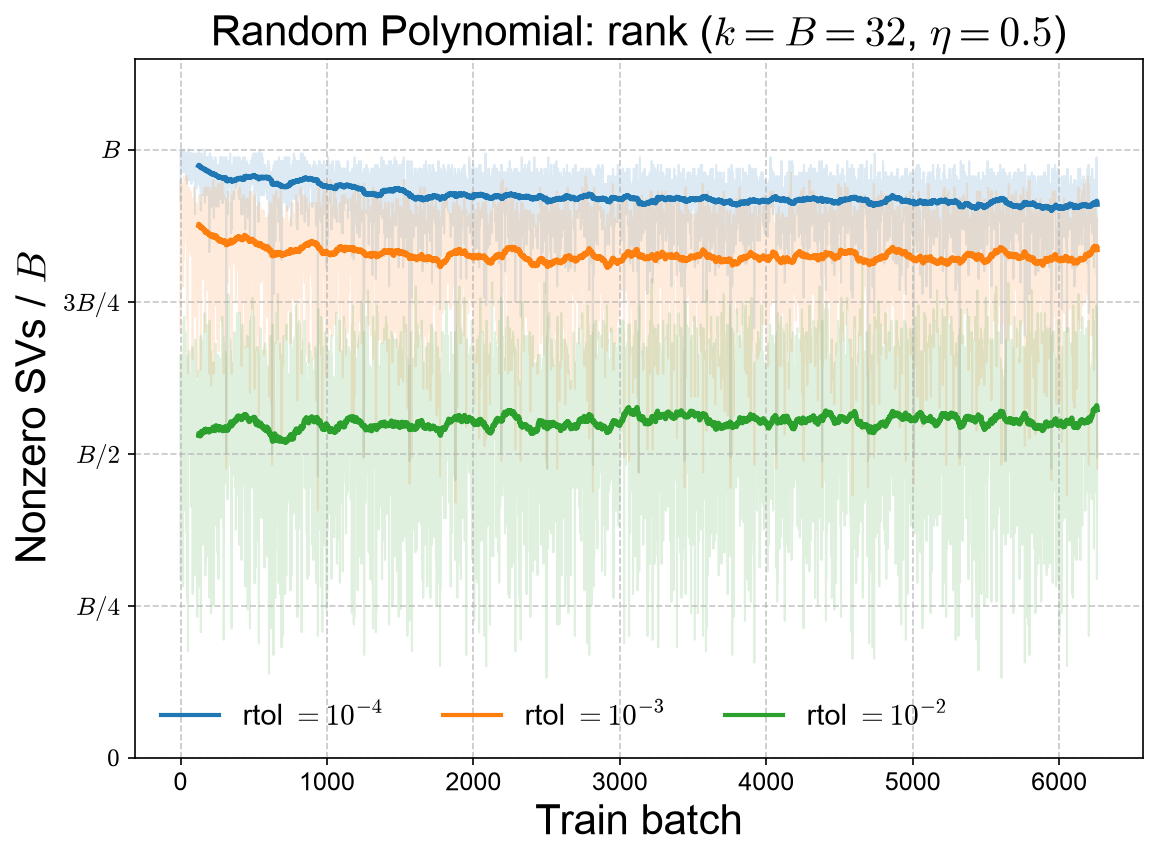

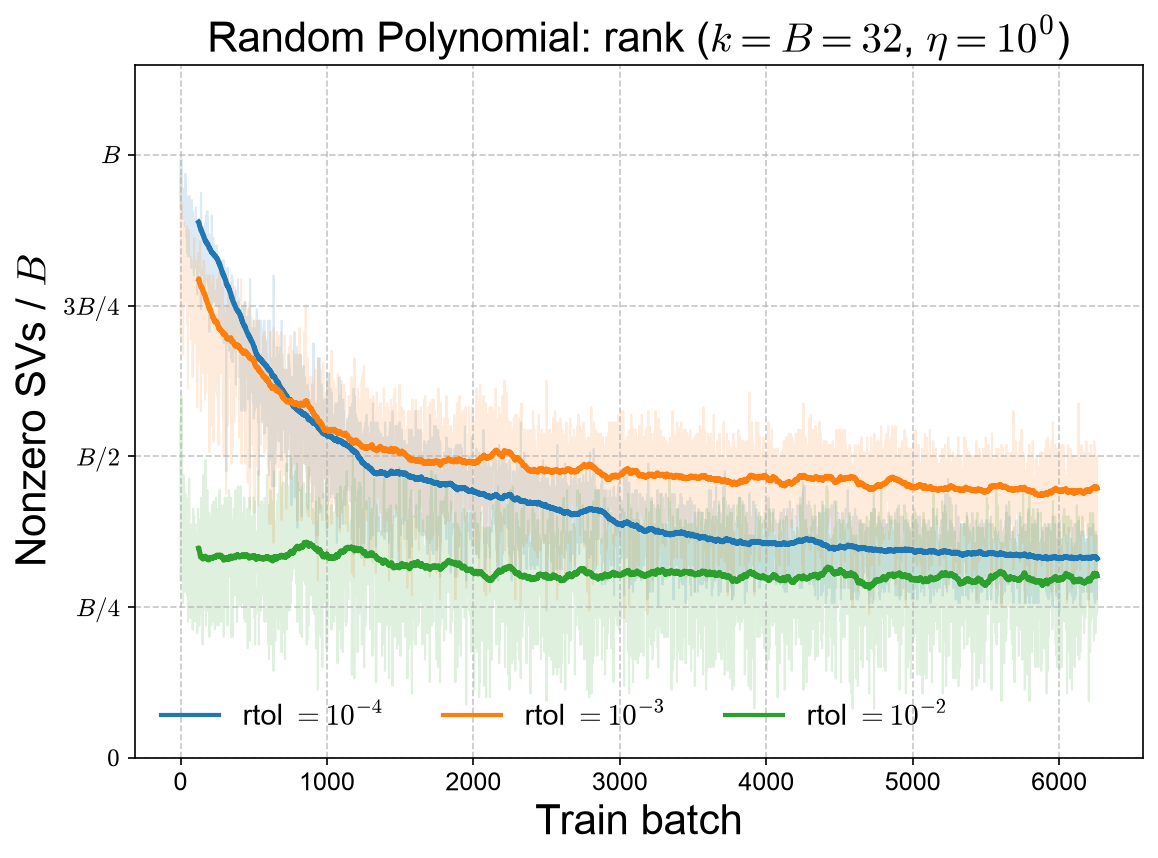

In [14]:
for lr in scan.sven_lrs:
    fig, ax = plt.subplots(figsize=(8, 6))
    handles = sa.plot_sv_rank(scan, ax, lr=lr, lw=2.5)
    if not handles:
        plt.close(fig)
        continue
    ax.legend(handles=handles, loc='lower left', ncol=min(3, len(handles)), frameon=False)
    ax.grid(axis='both', linestyle='--', alpha=0.7)
    fig.tight_layout()
    scan.save(fig, f'sv_rank_vs_batch_lr{lr:g}.pdf')
    plt.show()

### 5.2 Number of SVs used vs train batch

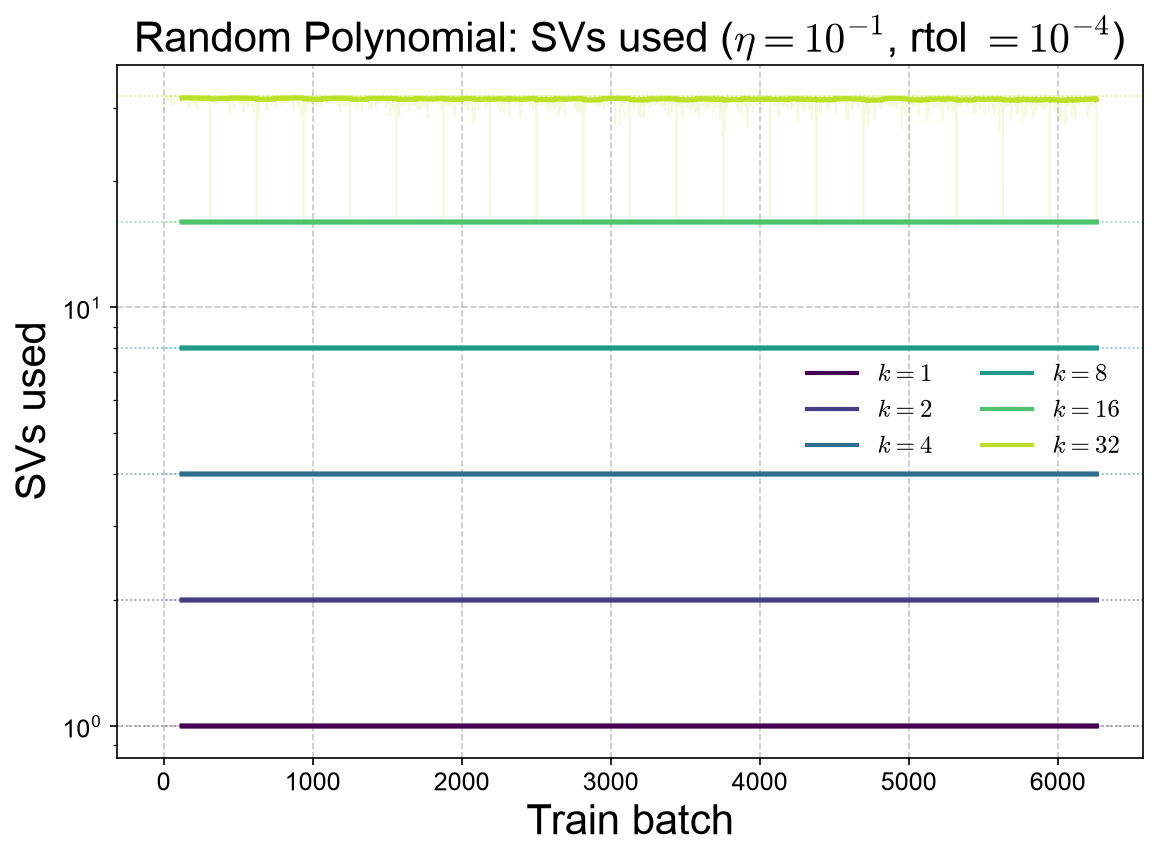

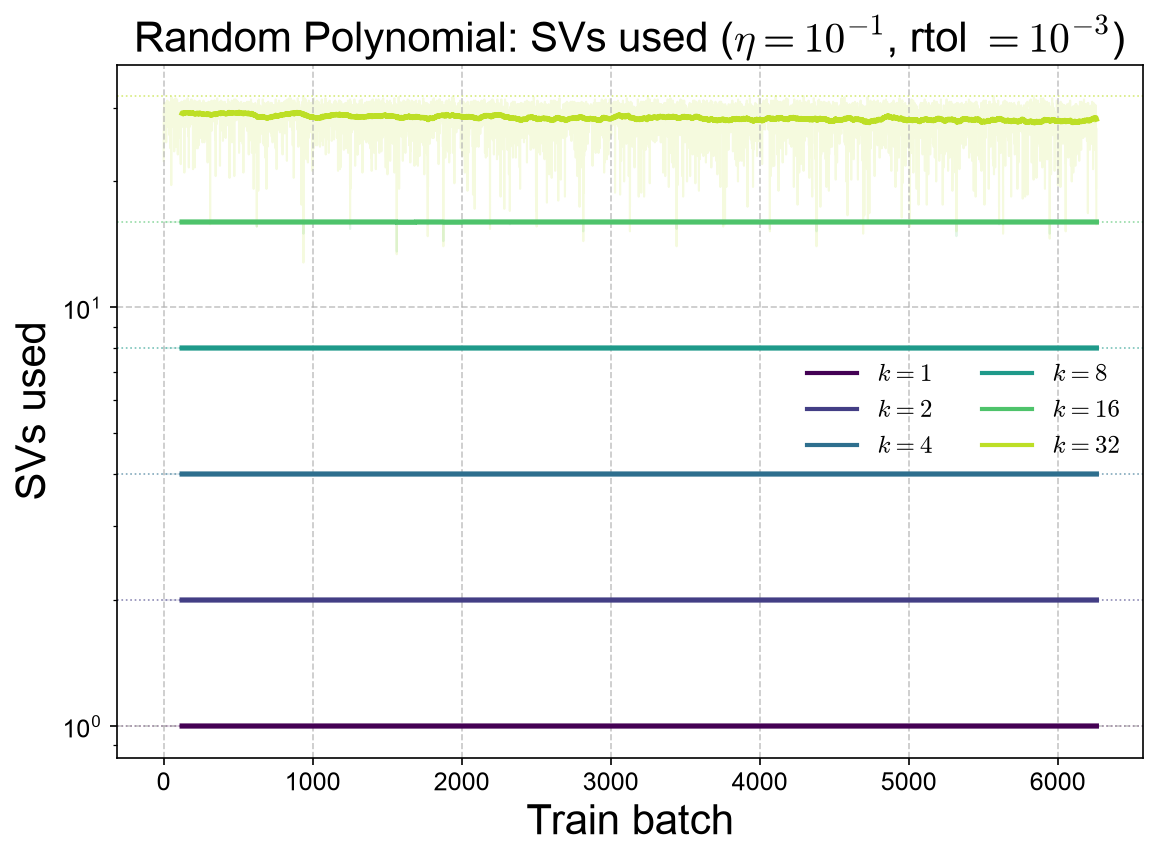

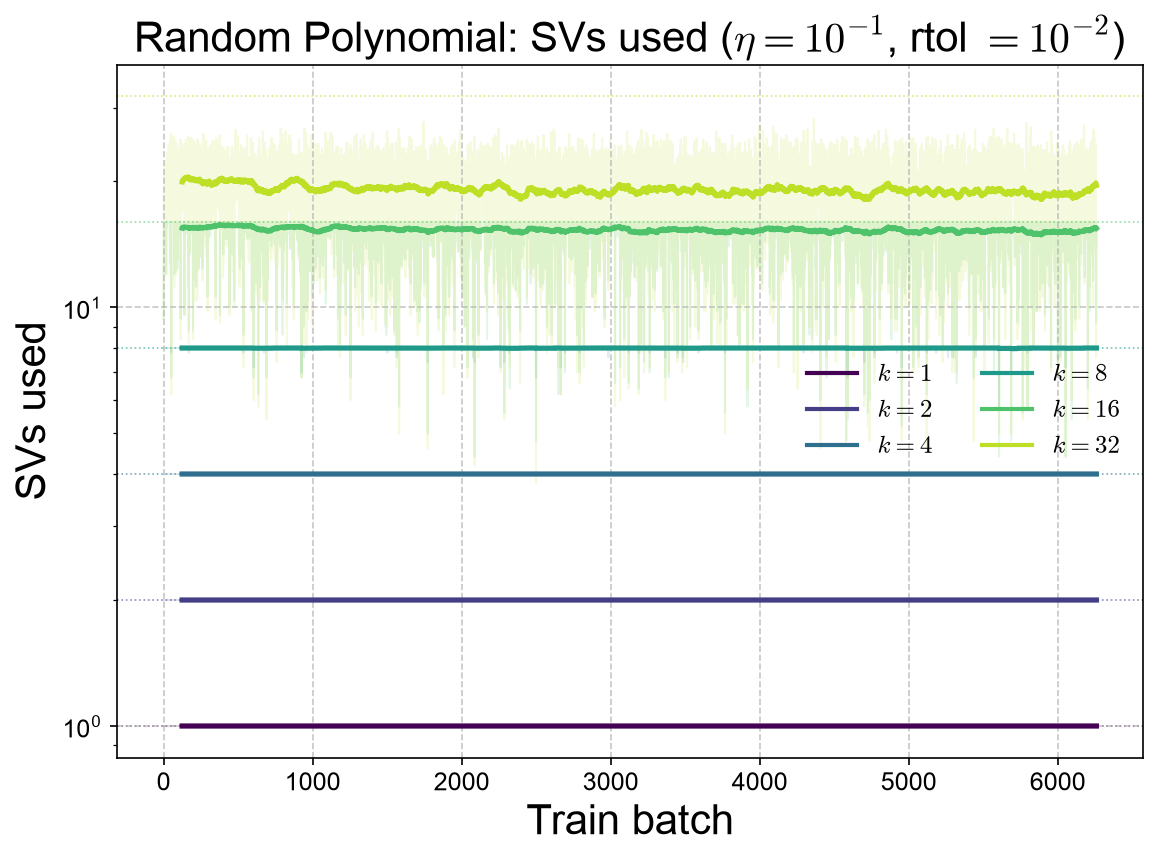

In [15]:
for rtol in scan.rtols:
    fig, ax = plt.subplots(figsize=(8, 6))
    handles = sa.plot_sv_used(scan, ax, lr=FOCUS_LR, rtol=rtol, lw=2.5)
    if not handles:
        plt.close(fig)
        continue
    ax.legend(handles=handles, ncol=2, loc='center right', frameon=False, fontsize=12)
    ax.grid(axis='both', linestyle='--', alpha=0.7)
    fig.tight_layout()
    scan.save(fig, f'sv_used_vs_batch_lr{FOCUS_LR:g}_rtol{rtol:g}.pdf')
    plt.show()

### 5.3 Spectrum shape per epoch

$\sigma_i/\sigma_0$, averaged over the batches within each epoch and over seeds.

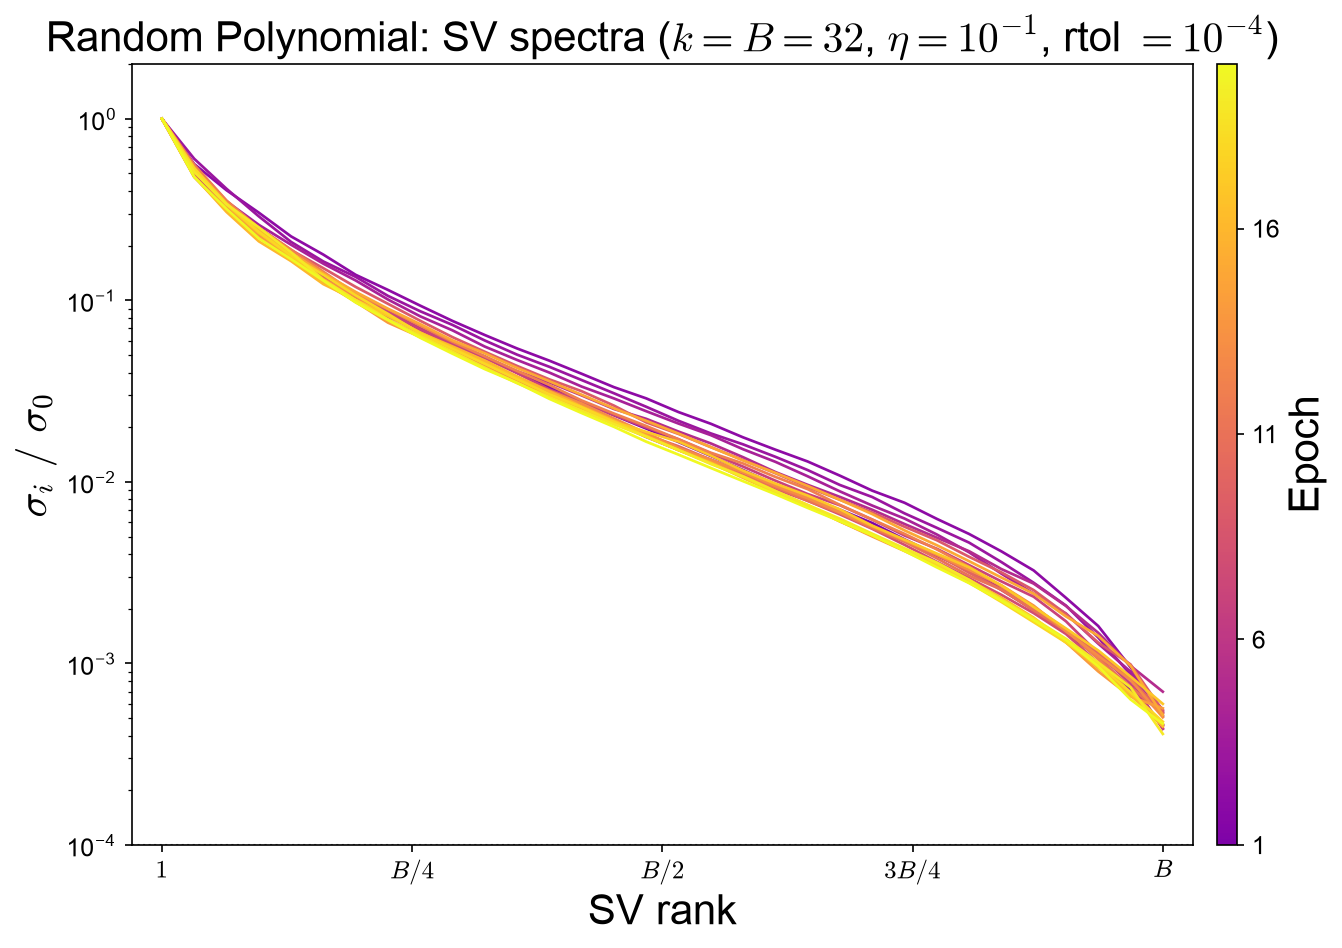

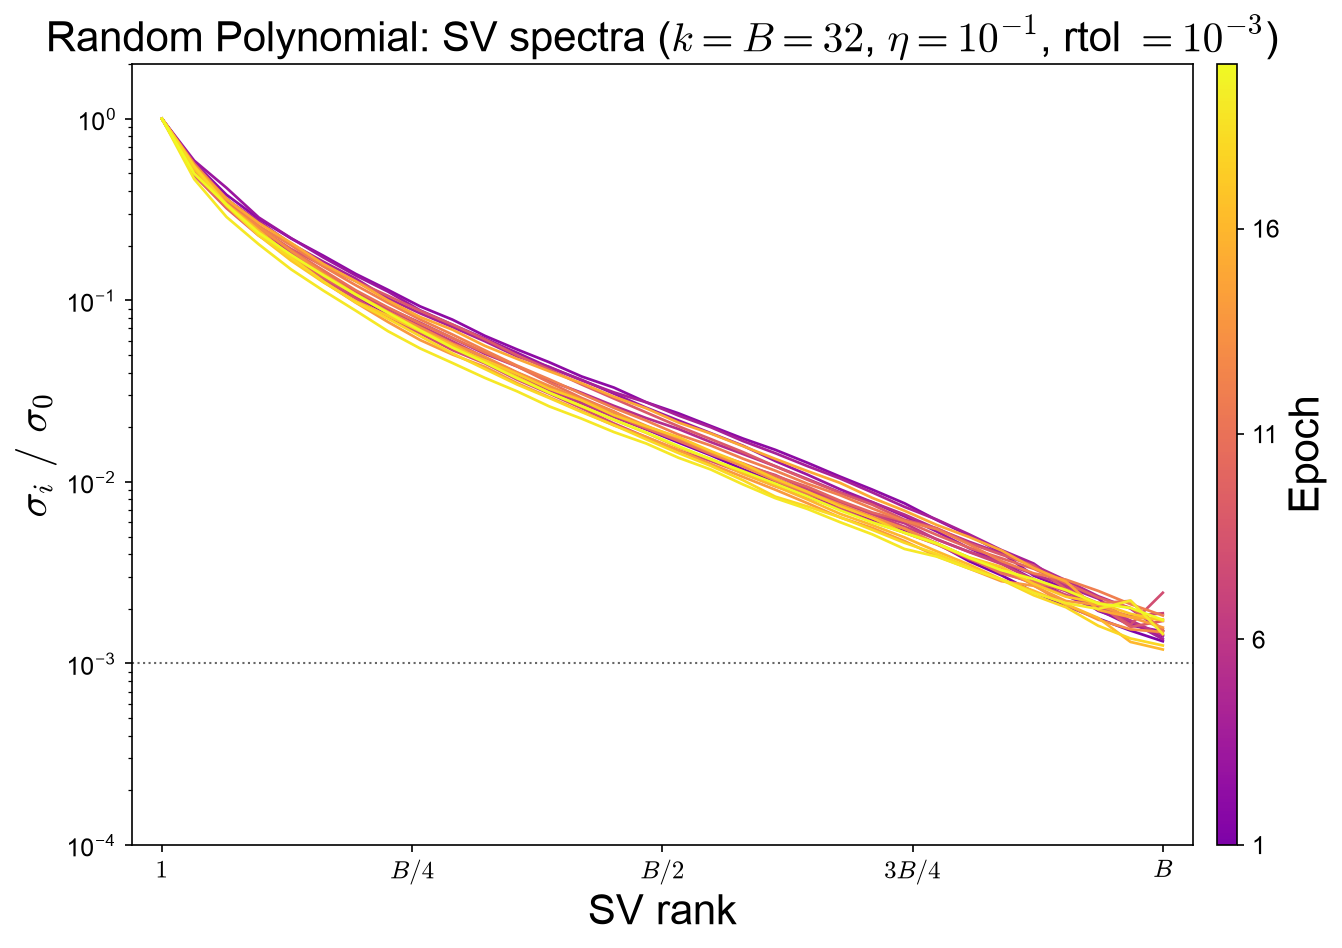

  [plot_epoch_spectra] recorded spectra are truncated at rtol (30 of 32 SVs, k=32, lr=0.1, rtol=0.01) -- rerun these runs with the full-spectrum logging to fix the tail


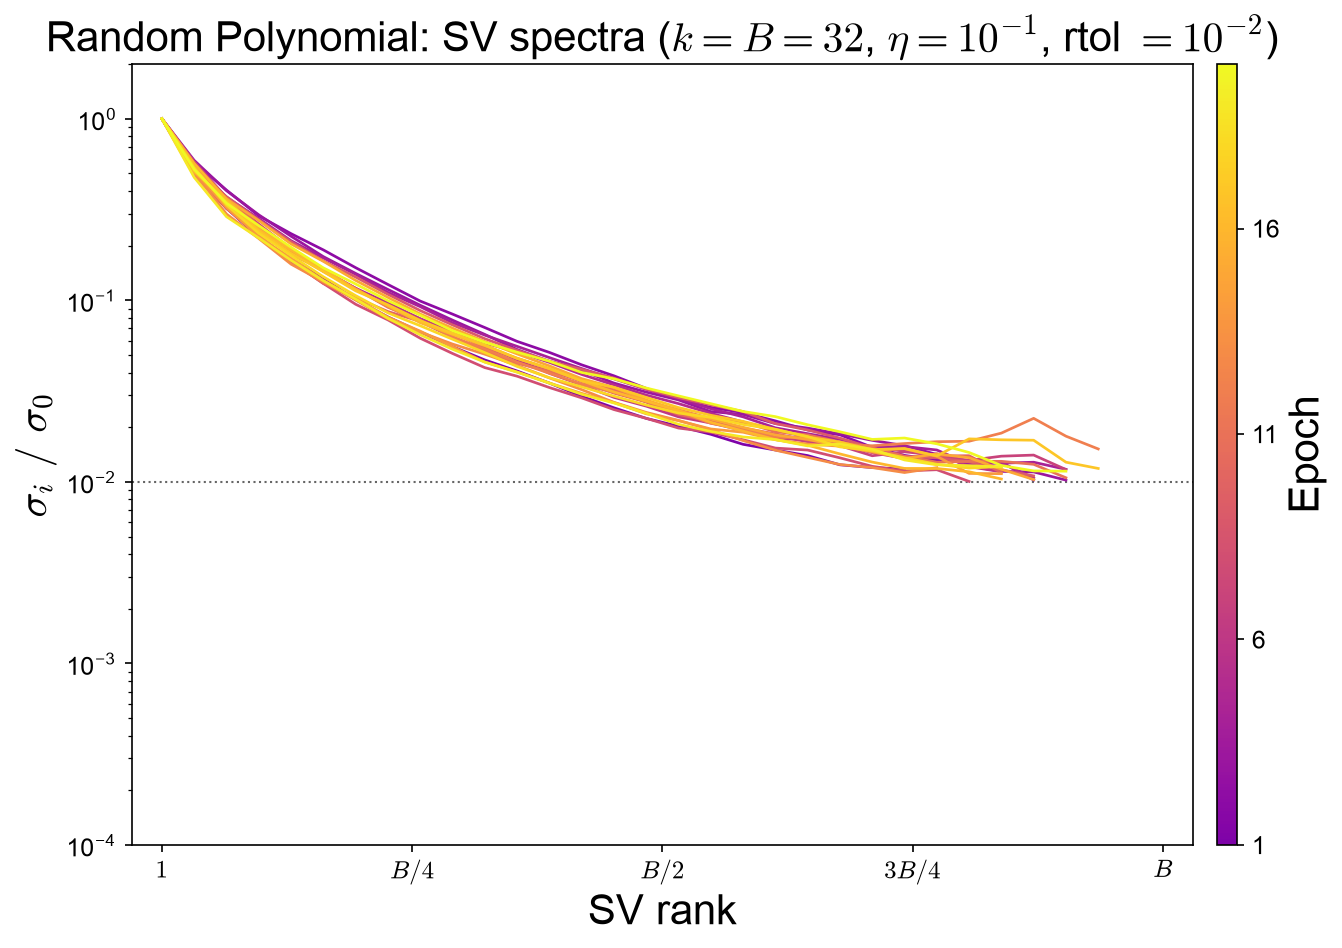

In [16]:
for rtol in scan.rtols:
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.tight_layout()
    spectra = sa.plot_sv_spectra(scan, fig, ax, lr=FOCUS_LR, rtol=rtol)
    if spectra is None:
        plt.close(fig)
        continue
    scan.save(fig, f'sv_spectra_per_epoch_lr{FOCUS_LR:g}_rtol{rtol:g}.pdf')
    plt.show()

## 6. Wall time

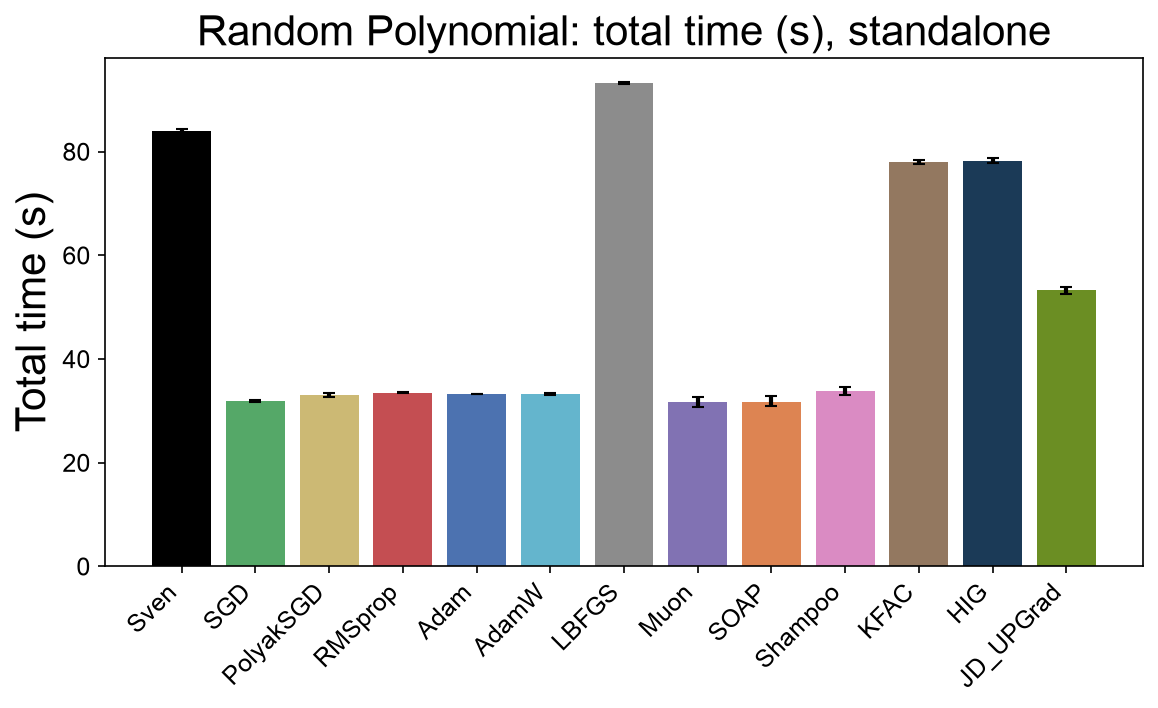

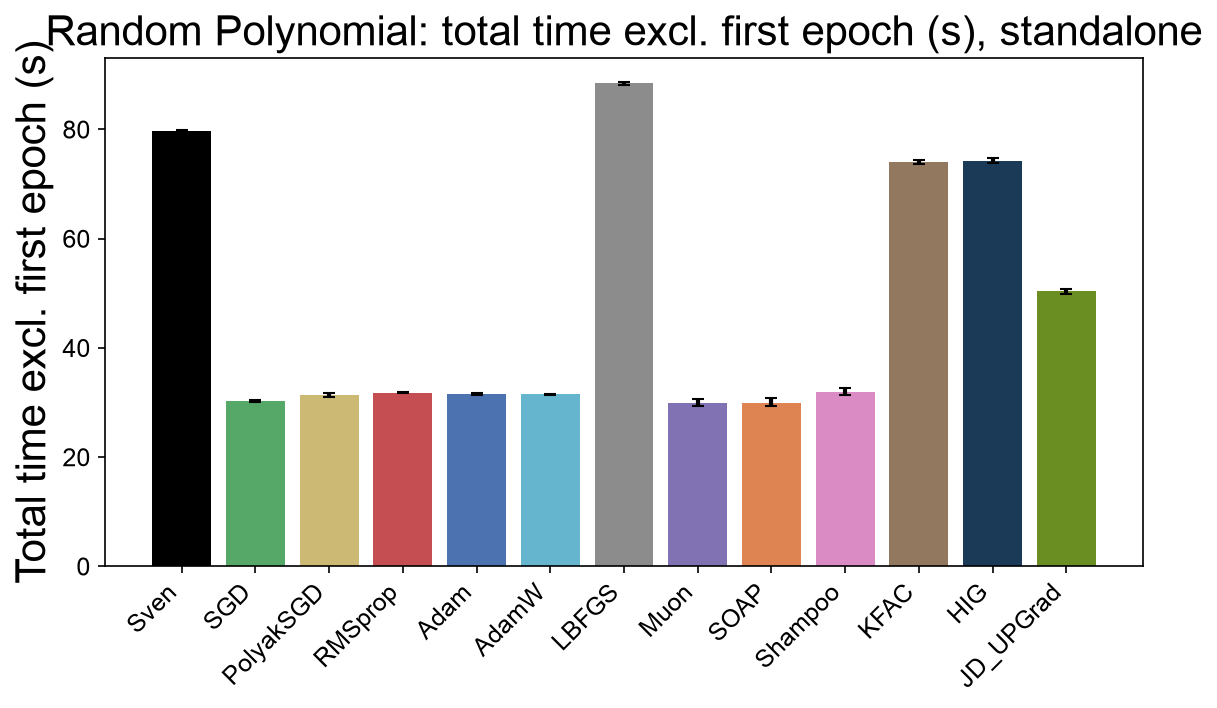

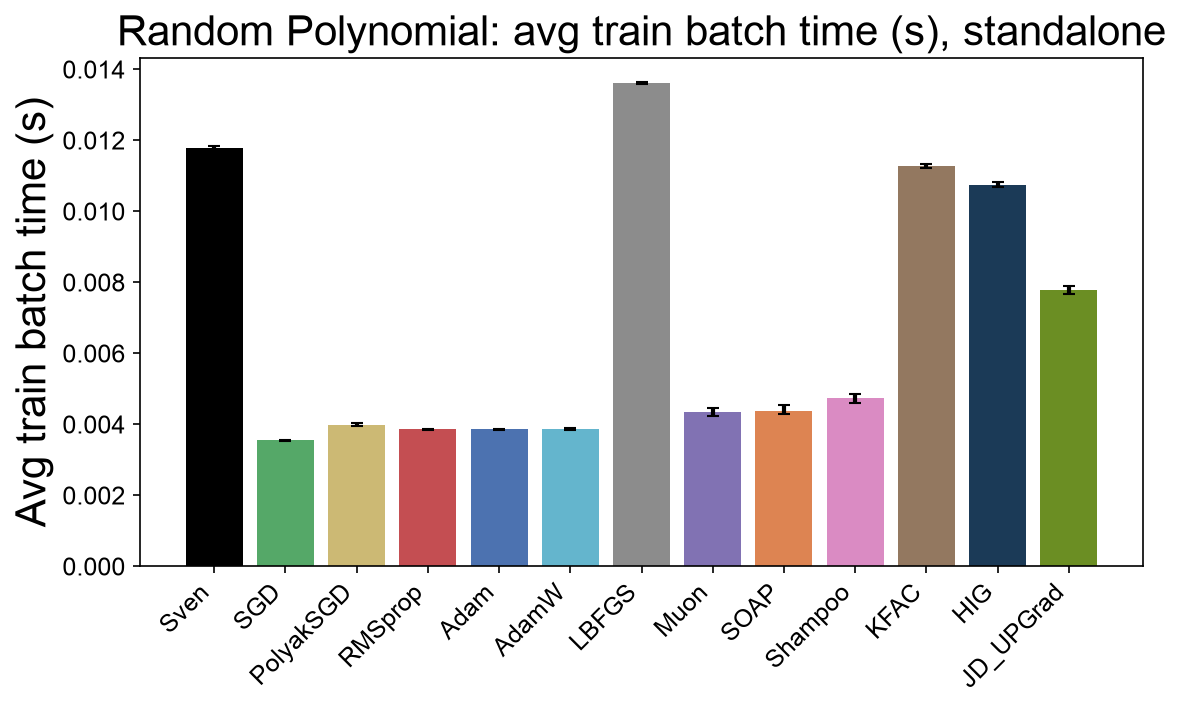

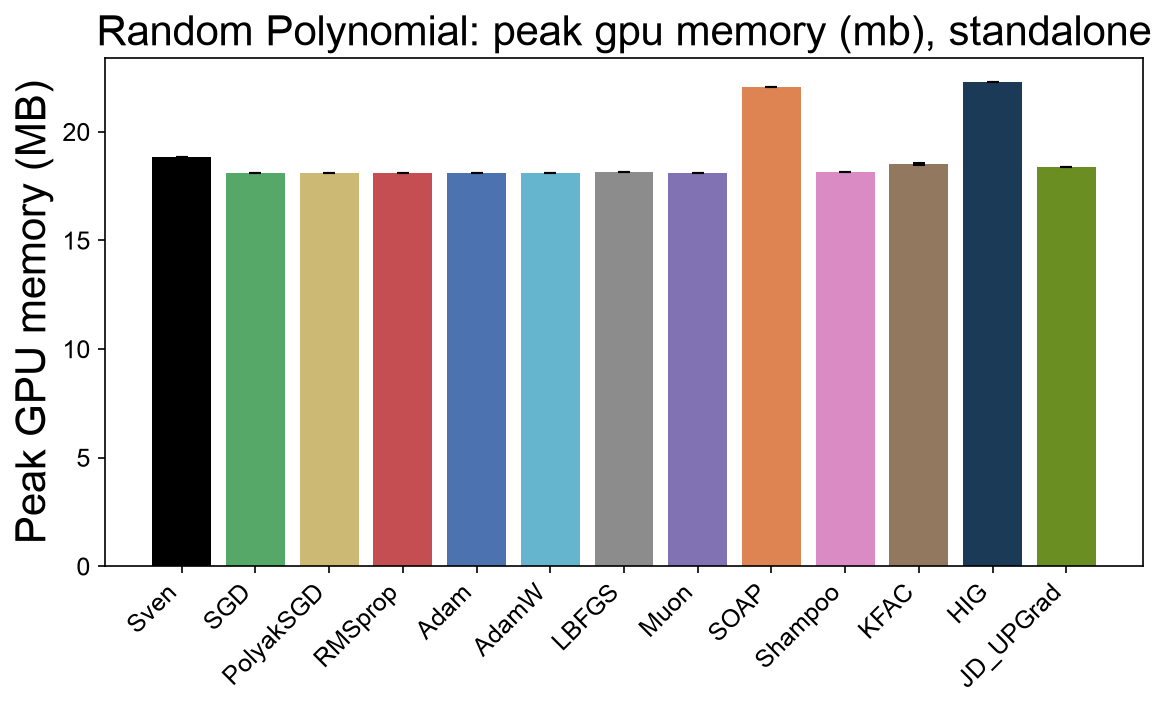

In [17]:
for quantity, fname, ylabel in [
        ('total_time', 'total_time_best_configs', 'Total time (s)'),
        ('time_excl_first_epoch', 'total_time_excl_first_epoch',
         'Total time excl. first epoch (s)'),
        ('avg_batch_time_train', 'avg_batch_time_best_configs', 'Avg train batch time (s)'),
        ('peak_gpu_mem_mb', 'peak_gpu_mem_best_configs', 'Peak GPU memory (MB)')]:
    fig, ax = plt.subplots(figsize=(8, 5))
    # standalone values when attach_standalone_times found them, else the sharded scan's
    values, _, source = sa.plot_time_summary(scan, ax, quantity, baselines=BASELINES)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{scan.title}: {ylabel.lower()}, {"standalone" if source == "standalone" else "sharded scan"}')
    fig.tight_layout()
    scan.save(fig, f'{fname}.pdf')
    plt.show()

### Honest wall time: standalone runs

The scan ran several trainings per GPU, so its `total_time` / `epoch_times` are inflated
(unevenly: Sven shared its GPU with LBFGS/K-FAC shards). `submit_timing_runs.sh` re-ran the
best configuration of each method alone on a GPU with identical seeds. `attach_standalone_times`
verified the trajectories agree. Once attached, every timing plot in this notebook (section 3's
loss-vs-wall-time curves, the bars above) uses the standalone times automatically and says so;
the grouped bars below show the sharded-vs-standalone inflation itself.

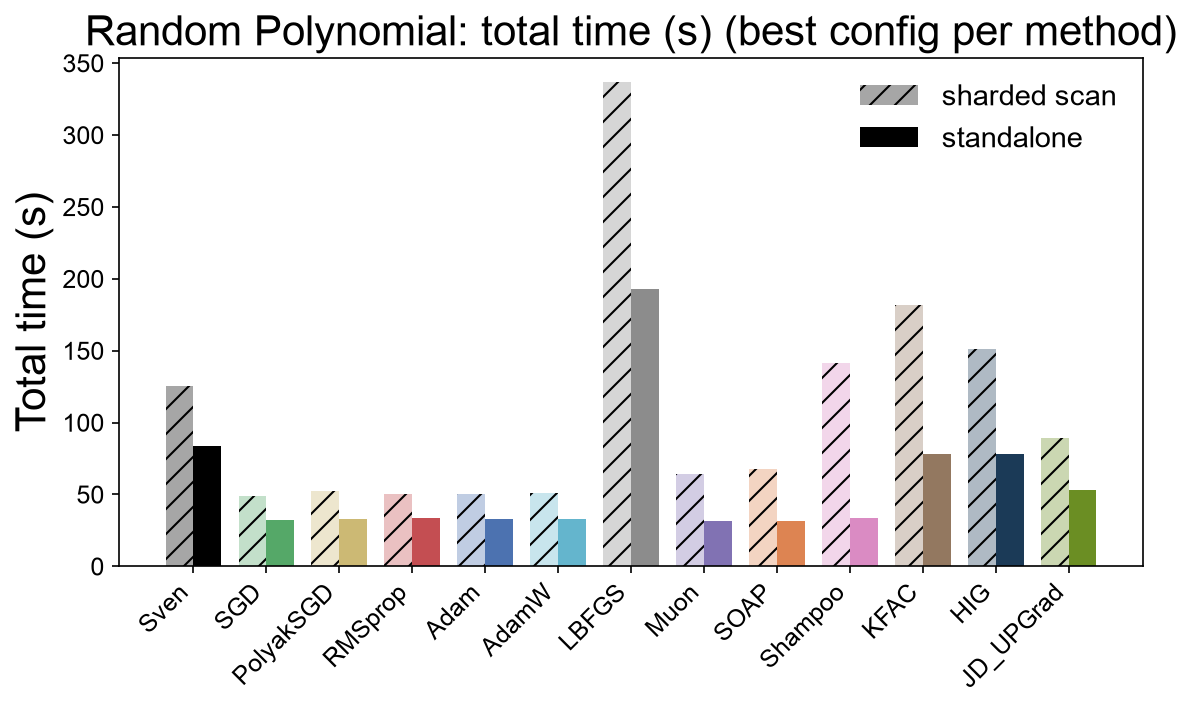

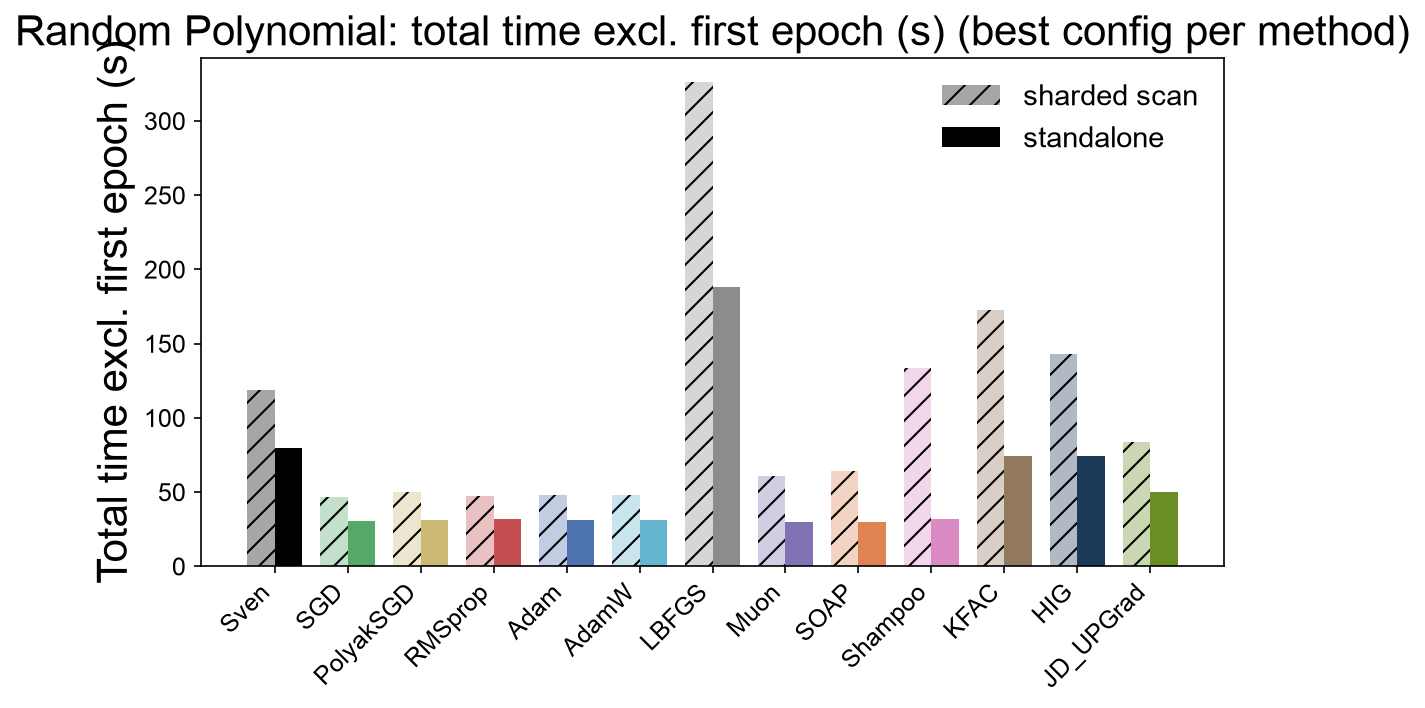

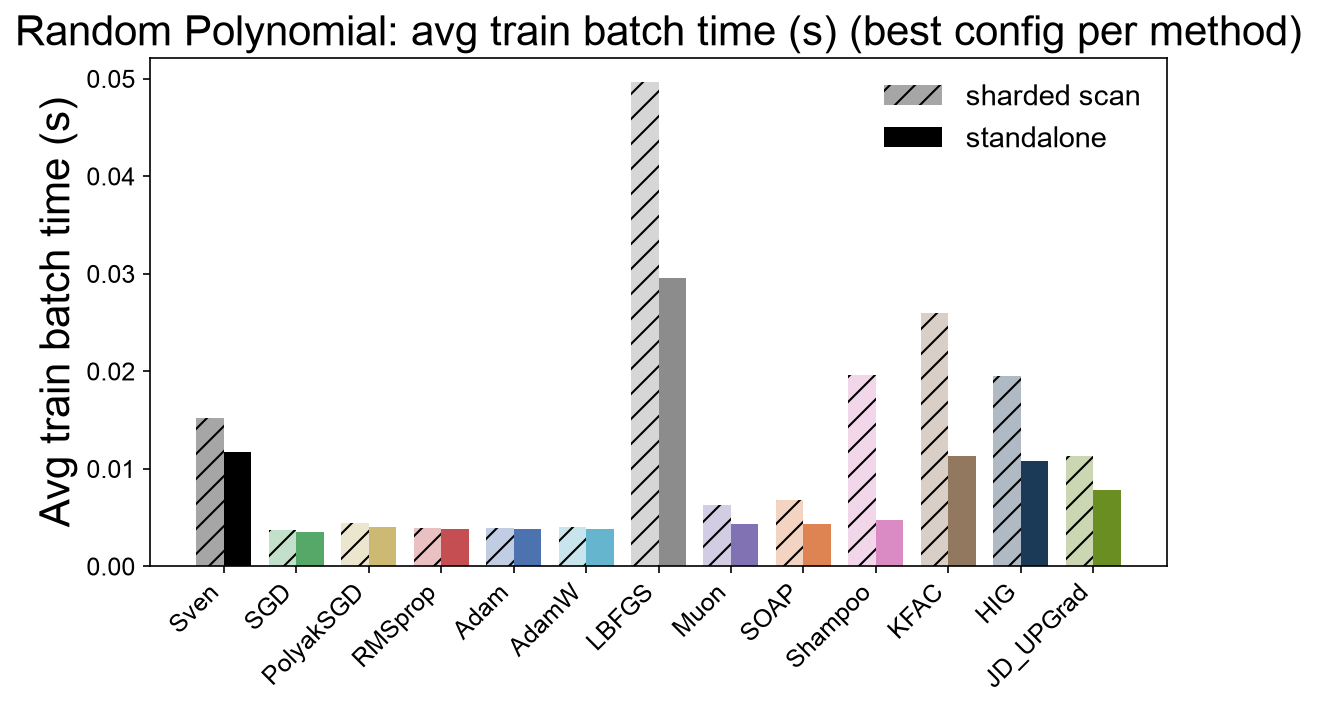

In [18]:
if timing is not None:
    for quantity, fname, ylabel in [
            ('total_time', 'standalone_total_time_best_configs', 'Total time (s)'),
            ('time_excl_first_epoch', 'standalone_total_time_excl_first_epoch',
             'Total time excl. first epoch (s)'),
            ('avg_batch_time_train', 'standalone_avg_batch_time_best_configs', 'Avg train batch time (s)')]:
        fig, ax = plt.subplots(figsize=(8, 5))
        sa.plot_time_comparison(scan, ax, quantity, baselines=BASELINES)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{scan.title}: {ylabel.lower()} (best config per method)')
        fig.tight_layout()
        scan.save(fig, f'{fname}.pdf')
        plt.show()

    # (the loss-vs-wall-time curves in section 3 already use these standalone times)

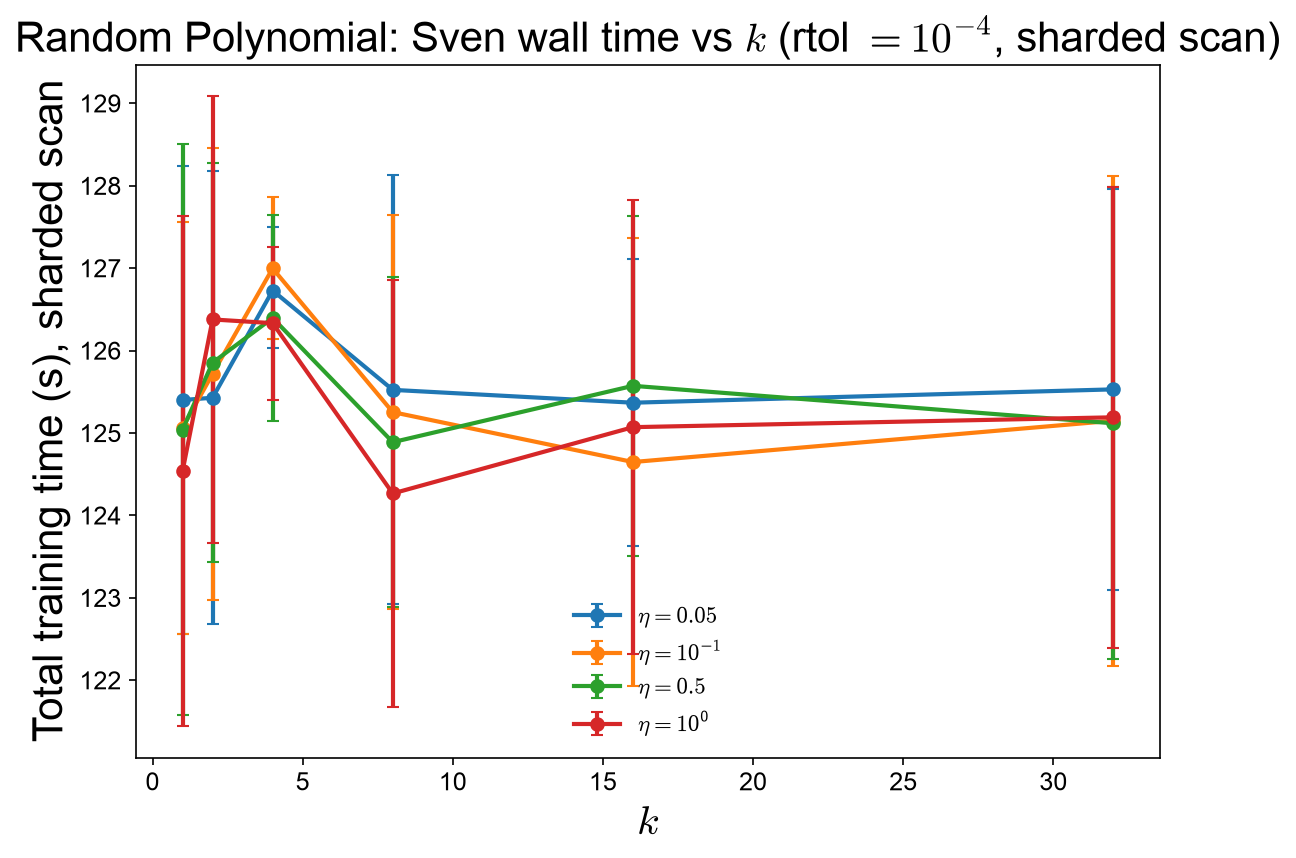

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
rtol = sa.plot_time_vs_k(scan, ax)   # seed mean +/- spread at the best config's rtol
ax.set_title(f'{scan.title}: Sven wall time vs $k$ (rtol $= {sa.fmt(rtol)}$, sharded scan)')
ax.legend(fontsize=11)
fig.tight_layout()
scan.save(fig, 'sven_walltime_vs_k.pdf')
plt.show()

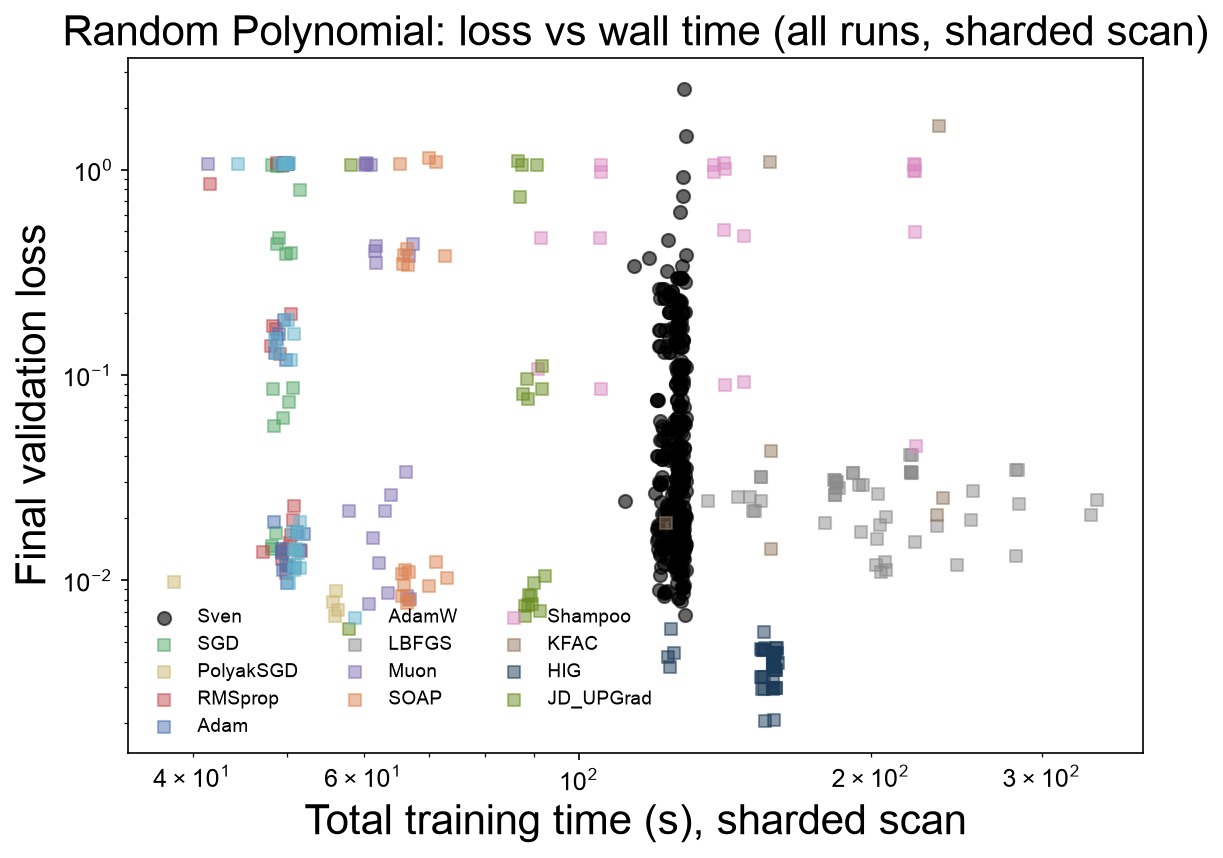

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sa.plot_efficiency(scan, ax, baselines=BASELINES)
ax.set_title(f'{scan.title}: loss vs wall time (all runs, sharded scan)')
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
scan.save(fig, 'efficiency_loss_vs_walltime.pdf')
plt.show()

## 7. Summary

In [21]:
print(f'{scan.name}: {len(scan.df)} runs, B={scan.B}, {scan.n_epochs} epochs, '
      f'{len(scan.seeds)} seeds')
print(f'Sven grid: k={scan.ks}, lr={scan.sven_lrs}, rtol={scan.rtols}')
print()
print(summary.to_string(index=False))
print()
print(f'Plots written to {scan.plot_dir.resolve()}')

polynomial_scan: 711 runs, B=32, 20 epochs, 5 seeds
Sven grid: k=[1, 2, 4, 8, 16, 32], lr=[0.05, 0.1, 0.5, 1.0], rtol=[0.0001, 0.001, 0.01]

   method                                            config  n_seeds  n_diverged  n_missing  final_val_loss  final_val_loss_std  final_val_loss_min  final_train_loss  sharded_time_s  standalone_time_s
      HIG                                  lr=0.1, tau=0.01        5           0          0        0.003039            0.000996            0.002052          0.002272      151.260698          78.254405
JD_UPGrad lr=0.001, aggregator=UPGrad, inner_optimizer=Adam        5           0          0        0.007276            0.000394            0.006710          0.005714       89.058085          53.278005
PolyakSGD                                                          5           0          0        0.008064            0.001266            0.006699          0.006868       52.555227          33.118509
     Muon                                          lr=0